In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_adaptive_mean_thresholding_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-10 21:20:52,121 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-05-10 21:20:52,127 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-05-10 21:20:52,140 - matplotlib - DEBUG - interactive is False
2026-05-10 21:20:52,141 - matplotlib - DEBUG - platform is linux
2026-05-10 21:20:52,196 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-05-10 21:20:52,198 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.ADAPTIVE_MEAN
CURRENT_DATASET = config.BLOODMNIST
CURRENT_RESOLUTION = 1 
specialist_name = "Adaptive Mean"
channel_names = [f"{specialist_name} - {c}" for c in ["Red", "Green", "Blue"]]

In [3]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [4]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_adaptive_mean_thresholding_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

20075


In [5]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_val  = Y_val.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [6]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="f1_macro")

[I 2026-03-14 20:12:15,398] A new study created in memory with name: no-name-ae49e54a-006f-4dce-80bc-f5fdc90cea89


[I 2026-03-14 22:49:50,265] Trial 0 finished with value: 0.7961603351359465 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7961603351359465.


[I 2026-03-15 01:37:13,911] Trial 1 finished with value: 0.7242230983906304 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7961603351359465.


[I 2026-03-15 04:44:20,287] Trial 2 finished with value: 0.8012962283177185 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.8012962283177185.


[I 2026-03-15 07:35:36,373] Trial 3 finished with value: 0.8214518327654812 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 3 with value: 0.8214518327654812.


...

[I 2026-03-20 03:44:24,035] Trial 46 finished with value: 0.8054289772120893 and parameters: {'s': 8.0, 'T': 5000, 'patch_size': 3, 'max_included_literals': 32}. Best is trial 14 with value: 0.8420184942477271.


[I 2026-03-20 06:20:48,300] Trial 47 finished with value: 0.8351113220614421 and parameters: {'s': 5.0, 'T': 10000, 'patch_size': 7, 'max_included_literals': 32}. Best is trial 14 with value: 0.8420184942477271.


[I 2026-03-20 08:49:18,953] Trial 48 finished with value: 0.814943854898287 and parameters: {'s': 5.0, 'T': 10000, 'patch_size': 7, 'max_included_literals': 32}. Best is trial 14 with value: 0.8420184942477271.


[I 2026-03-20 10:42:24,745] Trial 49 finished with value: 0.7691023414885204 and parameters: {'s': 2.0, 'T': 9500, 'patch_size': 5, 'max_included_literals': 512}. Best is trial 14 with value: 0.8420184942477271.


Best f1_macro: 0.8420184942477271
Best hyperparameters: {'s': 8.0, 'T': 5000, 'patch_size': 7, 'max_included_literals': 32}


In [7]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/adaptive_mean.json")

Best F1 score macro accuracy: 0.8420184942477271
Best hyperparameters: {'s': 8.0, 'T': 5000, 'patch_size': 7, 'max_included_literals': 32}


Best Optuna results saved to hyperparameters/adaptive_mean.json


In [6]:
best_value, best_params = load_optuna_best_results("hyperparameters/adaptive_mean.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [9]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BloodMNIST_Adaptive_Mean",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 75.33% (517.69s)


#2 Accuracy: 78.87% (458.98s)


#3 Accuracy: 77.14% (443.12s)


#4 Accuracy: 80.53% (436.91s)


...

#96 Accuracy: 85.88% (361.48s)


#97 Accuracy: 85.94% (362.62s)


#98 Accuracy: 86.14% (361.04s)


#99 Accuracy: 86.09% (360.91s)


#100 Accuracy: 85.62% (361.34s)


In [7]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BloodMNIST_Adaptive_Mean_Specialist.pkl")

In [7]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

NameError: name 'model_path' is not defined

In [8]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

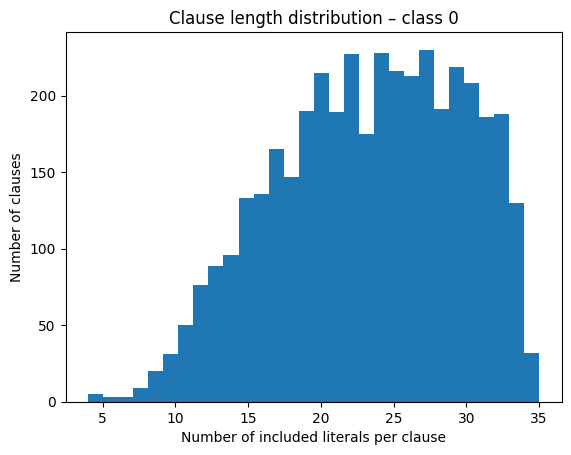

Class 0: median=24.0, mean=23.2, std=6.2


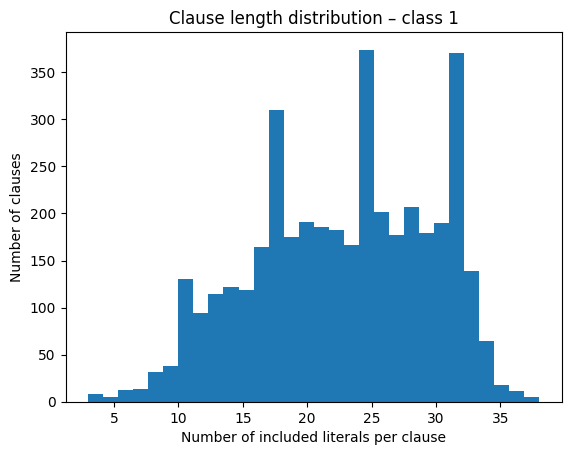

Class 1: median=23.0, mean=22.7, std=6.9


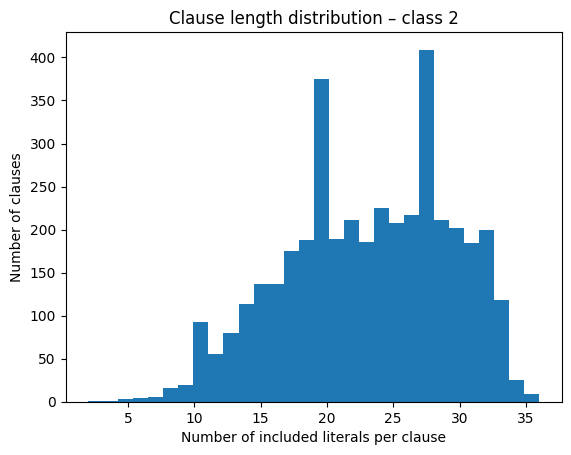

Class 2: median=24.0, mean=23.1, std=6.2


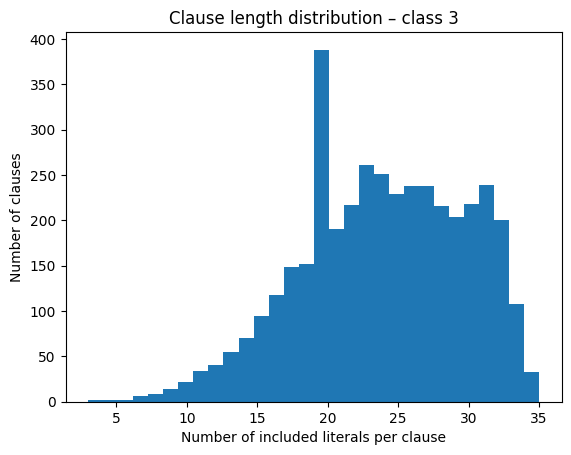

Class 3: median=24.0, mean=23.8, std=5.8


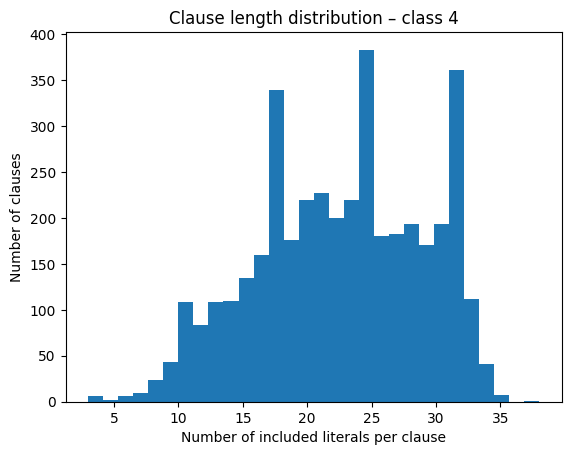

Class 4: median=23.0, mean=22.5, std=6.5


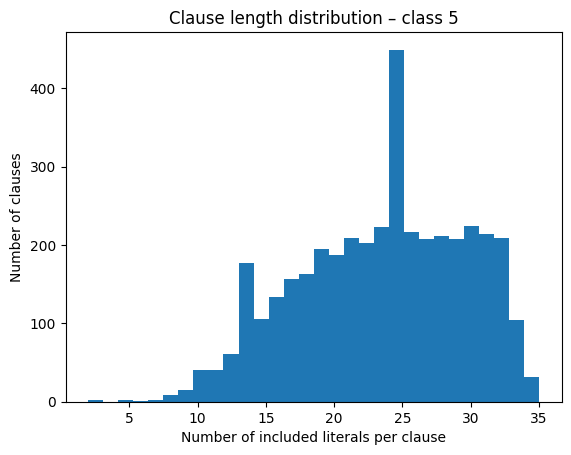

Class 5: median=24.0, mean=23.4, std=6.1


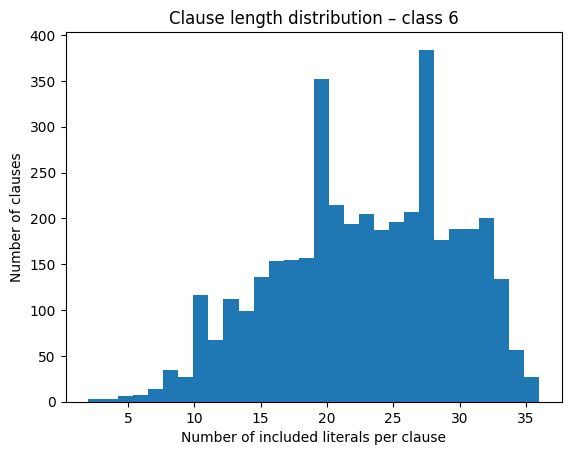

Class 6: median=23.0, mean=22.9, std=6.7


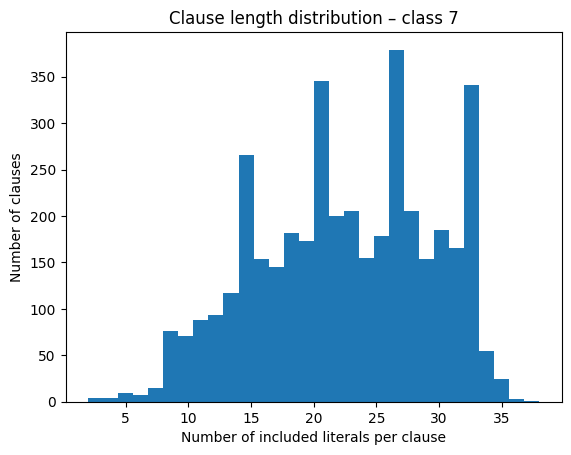

Class 7: median=23.0, mean=22.4, std=6.9


In [14]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 85.62%
2026-05-10 21:30:57,105 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ac79c6b0440>


Saved to saved_confusion_matrices/blood_adaptive_mean.svg


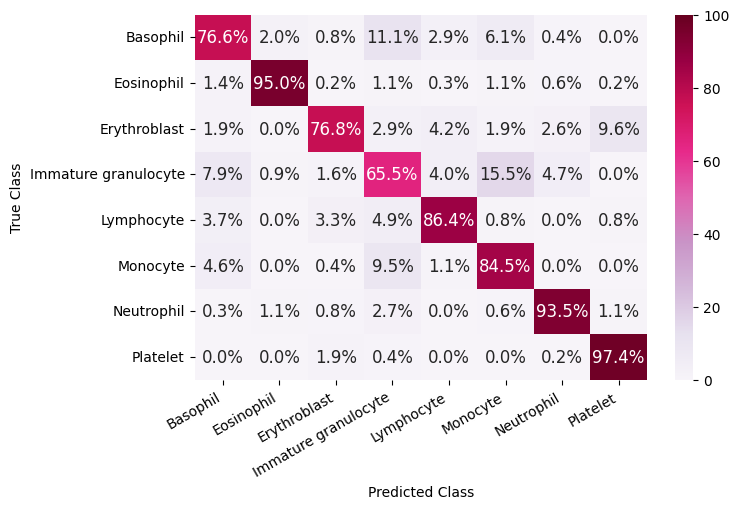

In [10]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="BloodMNIST_Adaptive_Mean", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, rotate_xlabels=True, figsize=(7.8, 5.2), cmap = "PuRd") 

# Class 0 Local Examples 

In [10]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

0
2026-04-15 11:34:20,022 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-15 11:34:20,026 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 888  |  predicted class: 0
2026-04-15 11:34:20,060 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7aef014c0f20>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c0_s888_aggr.svg


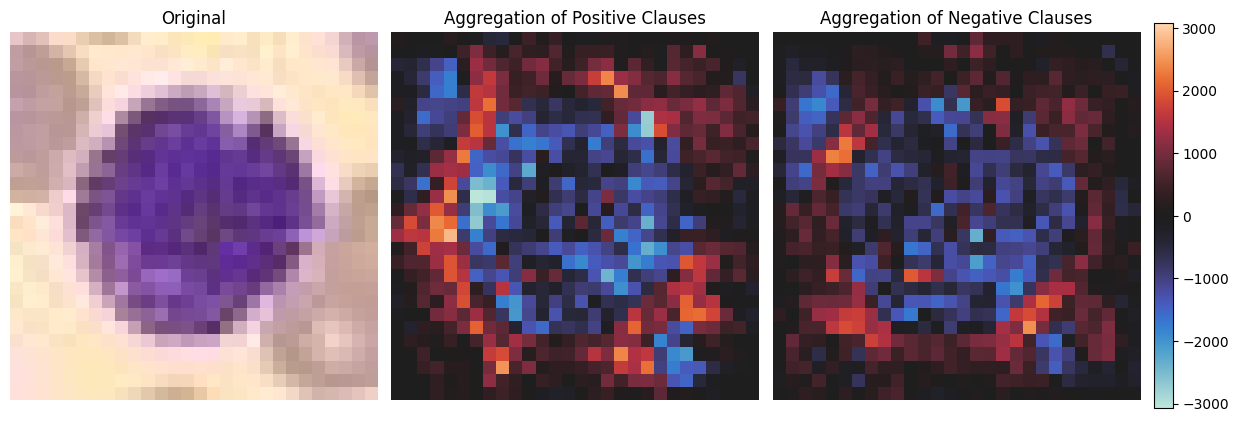

Visualizing sample 888  |  predicted class: 0
2026-04-15 11:34:24,170 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7aeef5fdbdd0>
2026-04-15 11:34:24,334 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7aeef5e0b3e0>
2026-04-15 11:34:24,366 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7aeef8080710>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c0_s888_chan.svg


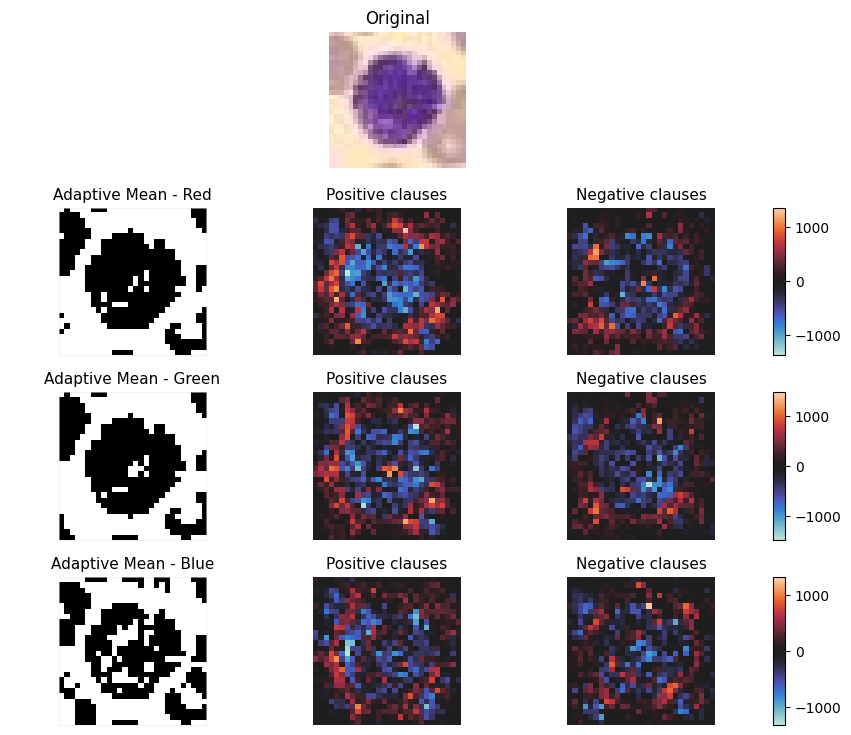

In [9]:
image_index =  888
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

0


Visualizing sample 542  |  predicted class: 0
2026-04-10 15:36:30,342 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549b77aa0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c0_s542_aggr.svg


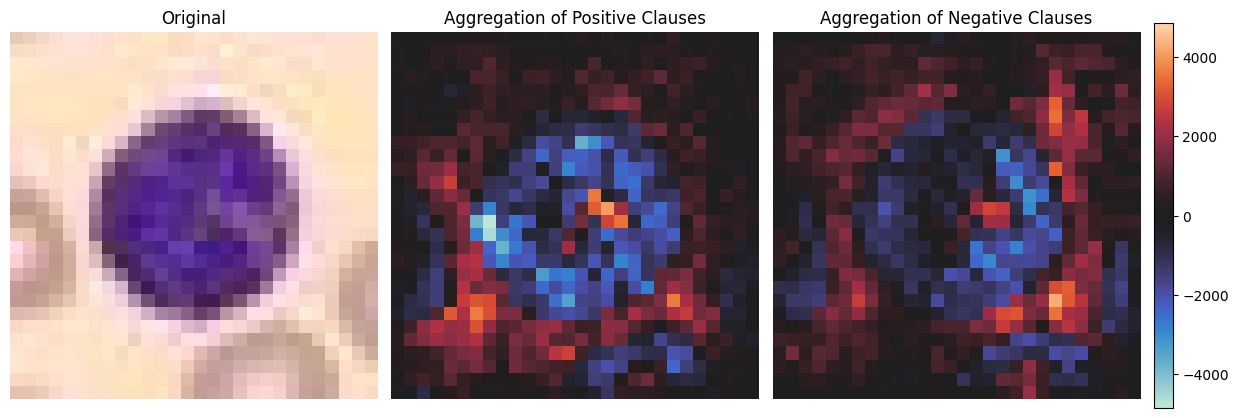

Visualizing sample 542  |  predicted class: 0
2026-04-10 15:36:34,965 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781548133080>
2026-04-10 15:36:35,036 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781548010410>
2026-04-10 15:36:35,064 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7815480ba270>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c0_s542_chan.svg


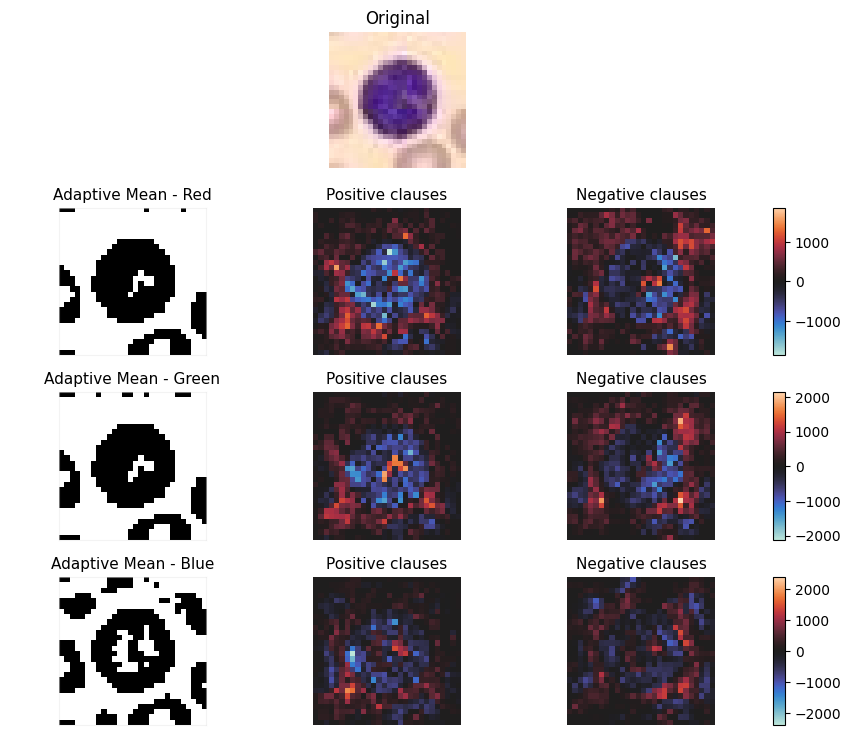

In [10]:
image_index =  542
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

0
Visualizing sample 2095  |  predicted class: 0
2026-04-10 15:36:41,502 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547e01c40>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c0_s2095_aggr.svg


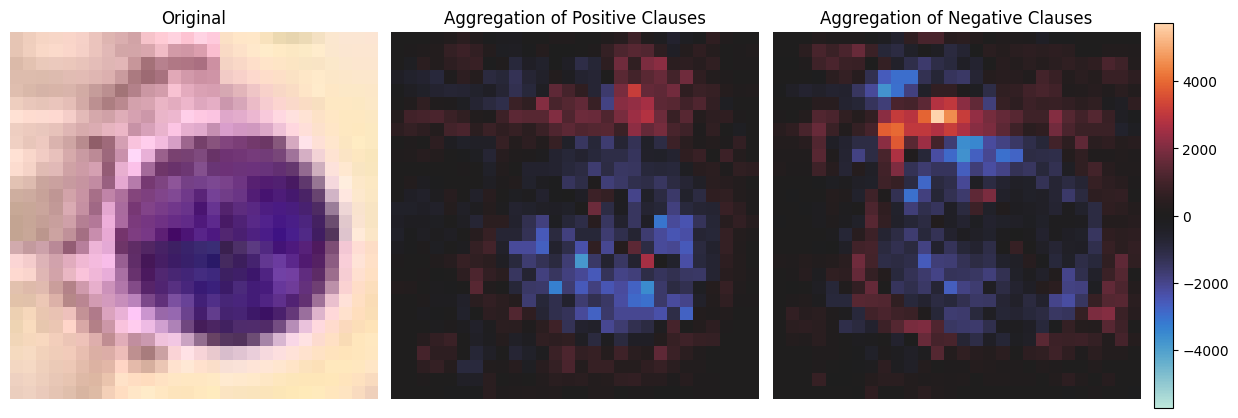

Visualizing sample 2095  |  predicted class: 0
2026-04-10 15:36:45,302 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7815480b8200>
2026-04-10 15:36:45,529 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547c18b90>
2026-04-10 15:36:45,558 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547c186b0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c0_s2095_chan.svg


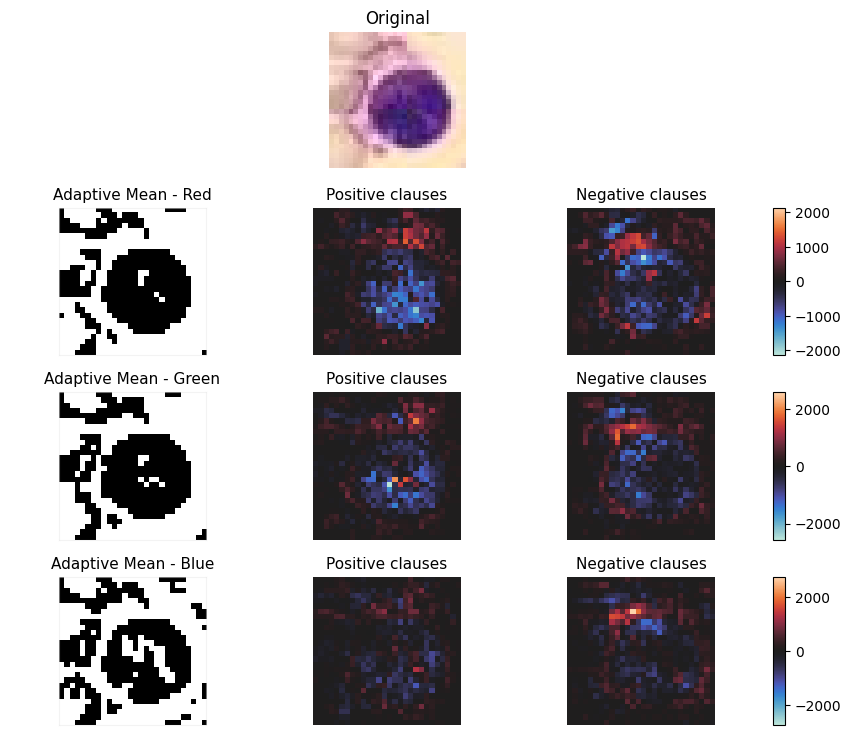

In [11]:
image_index =  2095
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 1 Local Examples 

In [12]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

1
Visualizing sample 880  |  predicted class: 1
2026-04-10 15:36:50,522 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154808ca70>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c1_s880_aggr.svg


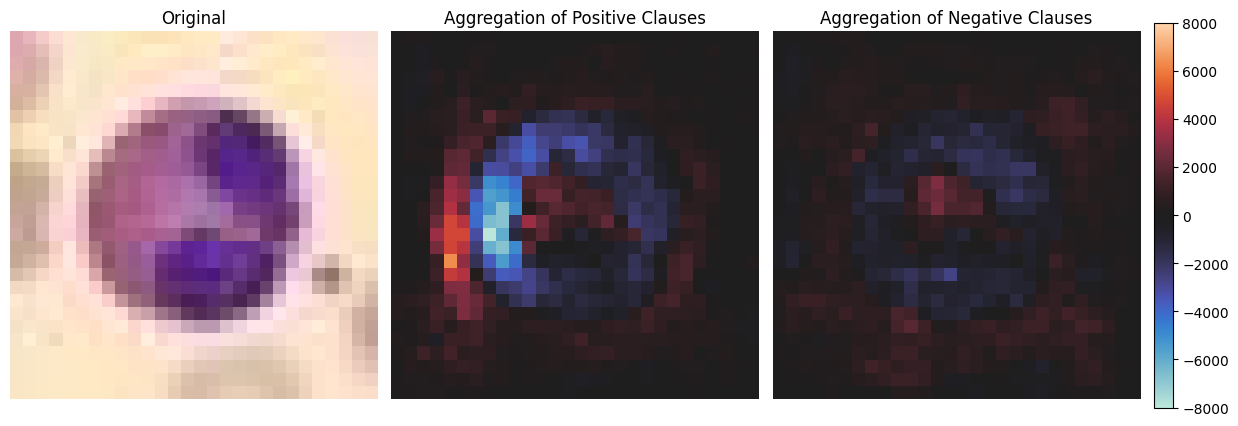

Visualizing sample 880  |  predicted class: 1
2026-04-10 15:36:55,229 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7815480de8d0>
2026-04-10 15:36:55,258 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547e26330>
2026-04-10 15:36:55,287 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549c9e510>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c1_s880_chan.svg


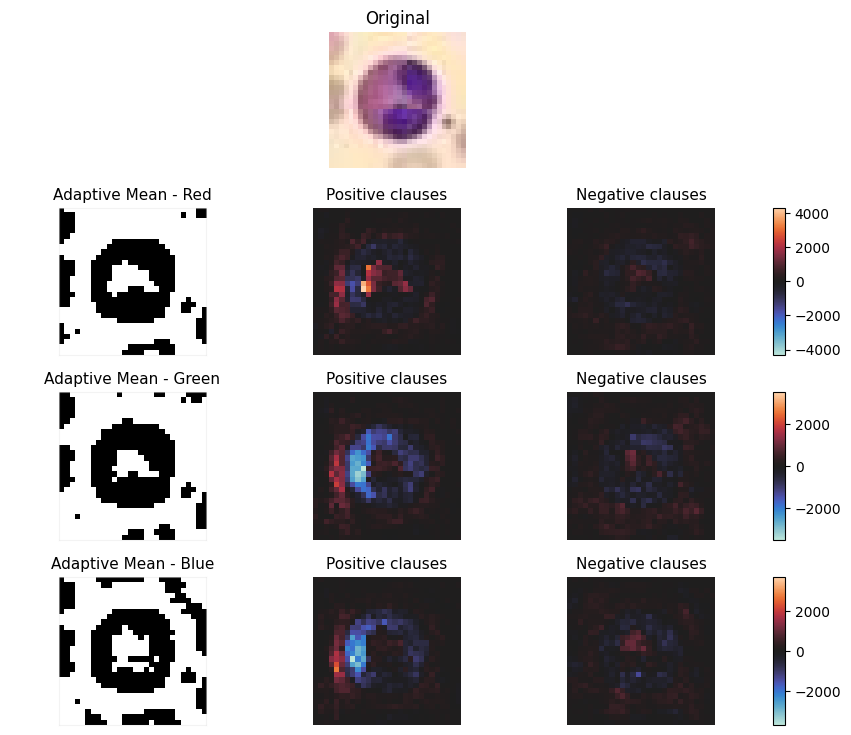

In [13]:
image_index =  880
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

1
Visualizing sample 2840  |  predicted class: 1
2026-04-10 15:37:00,347 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549cefd70>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c1_s2840_aggr.svg


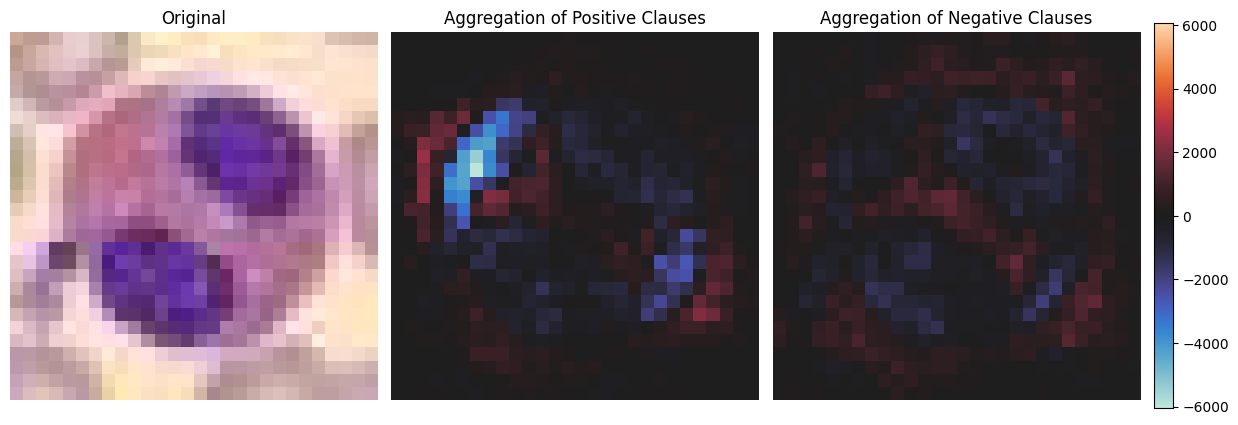

Visualizing sample 2840  |  predicted class: 1
2026-04-10 15:37:04,562 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549dbd670>
2026-04-10 15:37:04,592 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7815481deb10>
2026-04-10 15:37:04,781 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549c39b80>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c1_s2840_chan.svg


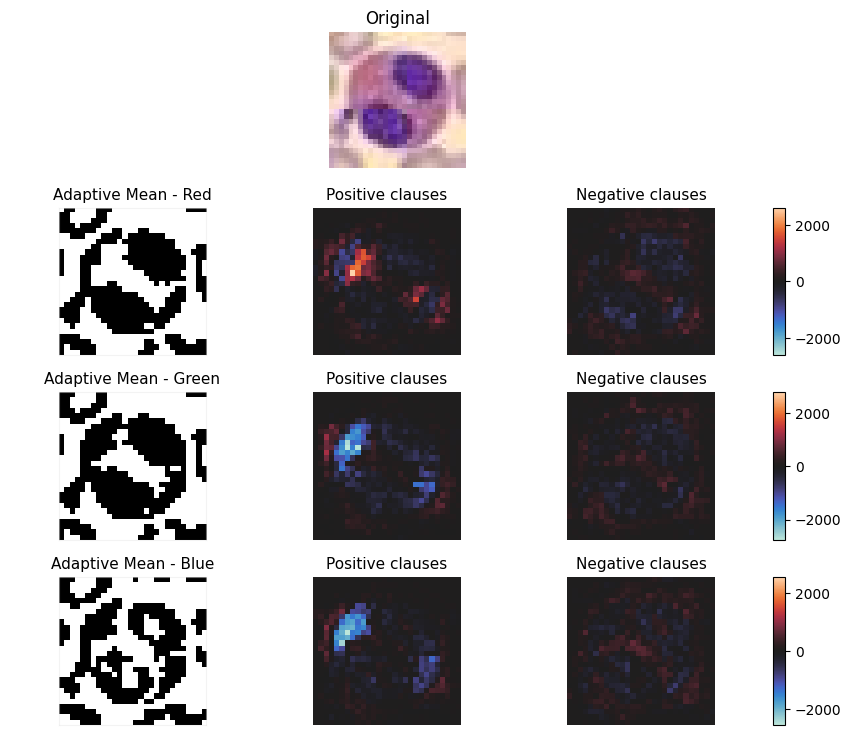

In [14]:
image_index =  2840
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

1
Visualizing sample 2328  |  predicted class: 1
2026-04-10 15:37:09,368 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154818f080>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c1_s2328_aggr.svg


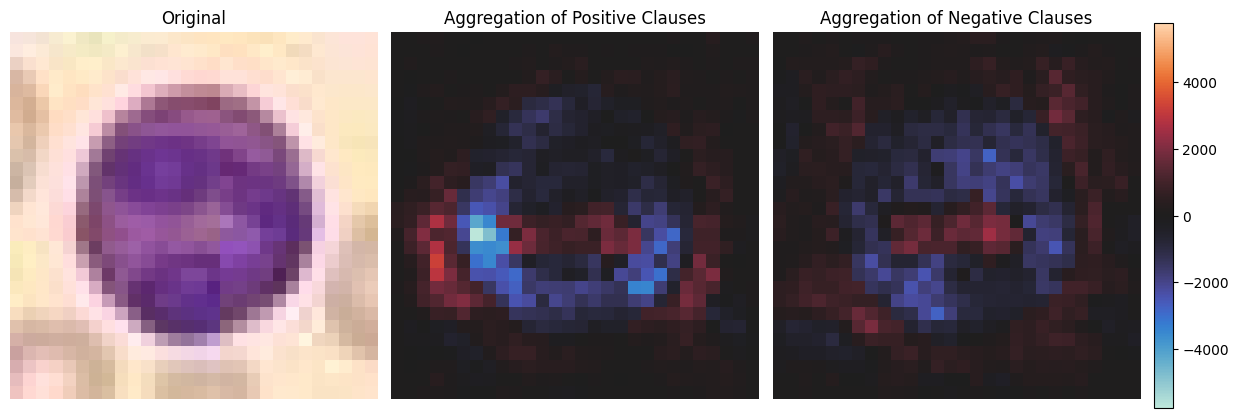

Visualizing sample 2328  |  predicted class: 1
2026-04-10 15:37:13,585 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547c48d40>
2026-04-10 15:37:13,615 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7815480106e0>
2026-04-10 15:37:13,644 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549cee240>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c1_s2328_chan.svg


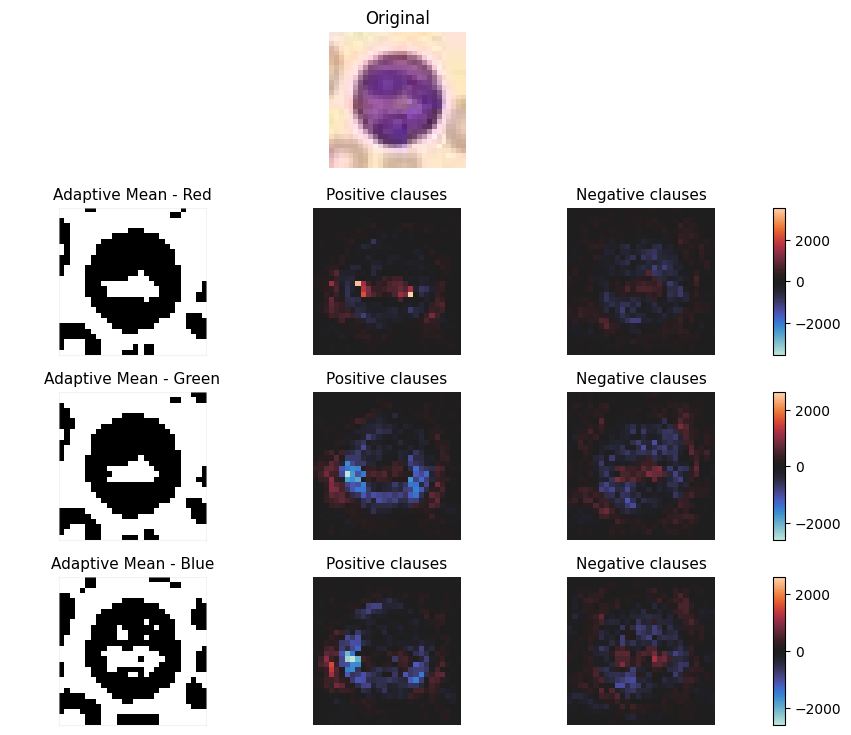

In [15]:
image_index =  2328
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 2 Local Examples 

In [16]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=2, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

2
Visualizing sample 3140  |  predicted class: 2
2026-04-10 15:37:18,485 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7815480dc530>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c2_s3140_aggr.svg


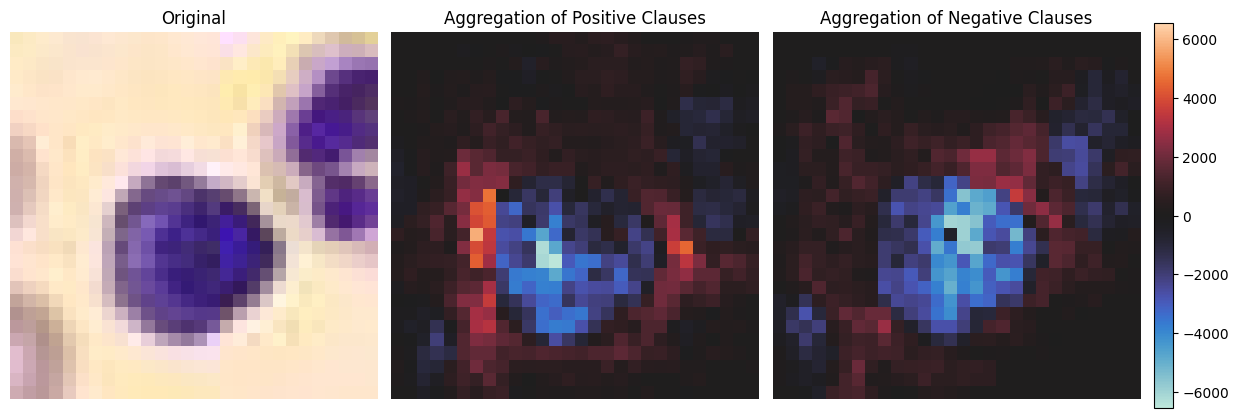

Visualizing sample 3140  |  predicted class: 2
2026-04-10 15:37:22,878 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547e78cb0>
2026-04-10 15:37:22,907 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549ba5910>
2026-04-10 15:37:22,936 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547fb6600>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c2_s3140_chan.svg


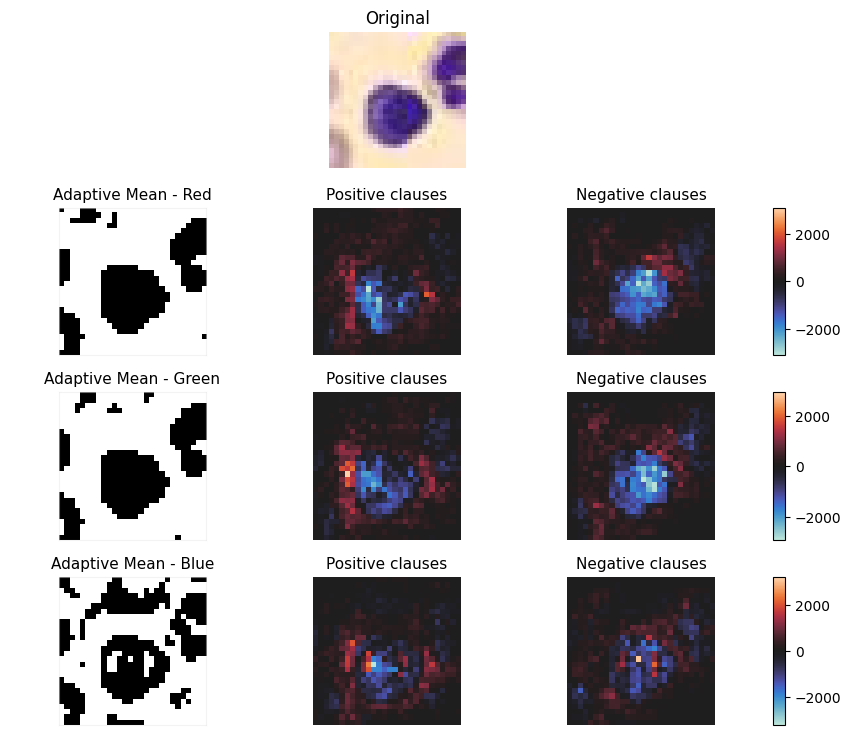

In [17]:
image_index =  3140
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

2
Visualizing sample 1511  |  predicted class: 2
2026-04-10 15:37:28,036 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549bd00e0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c2_s1511_aggr.svg


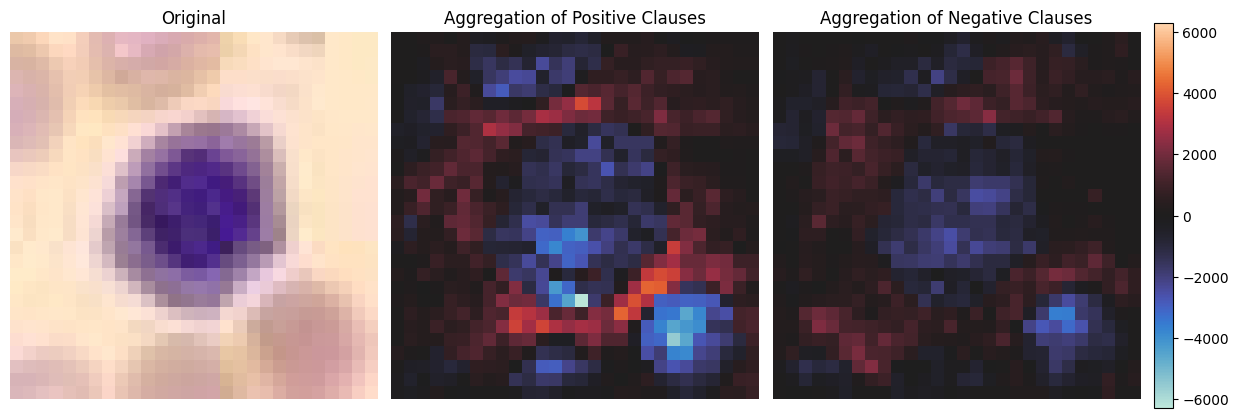

Visualizing sample 1511  |  predicted class: 2
2026-04-10 15:37:31,938 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549b77c80>
2026-04-10 15:37:31,965 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781548146150>
2026-04-10 15:37:31,992 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154bea5820>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c2_s1511_chan.svg


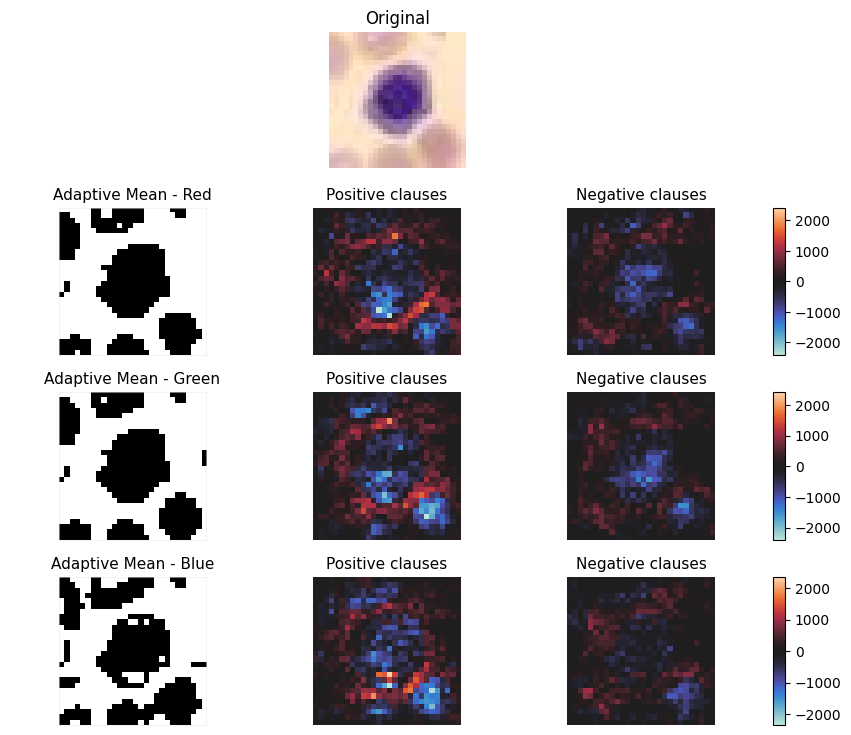

In [18]:
image_index =  1511
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

2


Visualizing sample 3000  |  predicted class: 2
2026-04-10 15:37:36,366 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154821ec30>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c2_s3000_aggr.svg


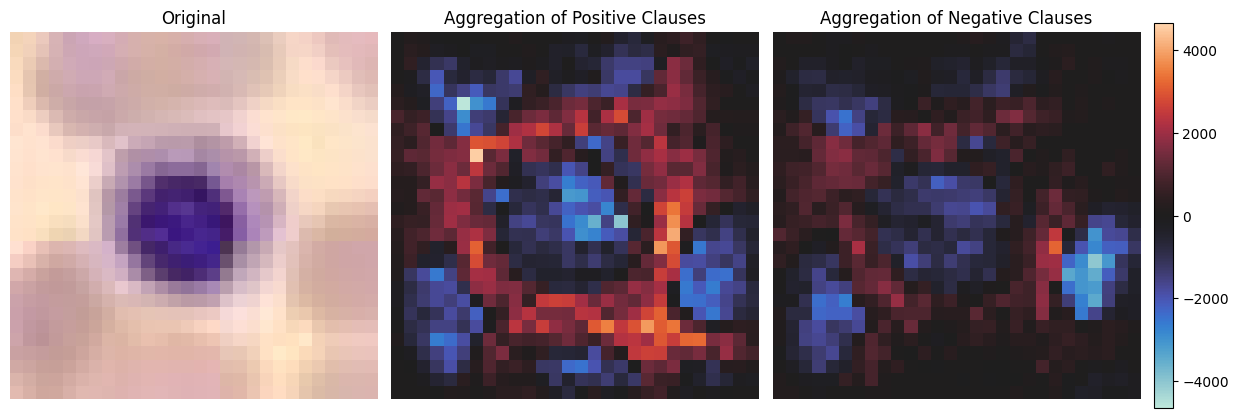

Visualizing sample 3000  |  predicted class: 2
2026-04-10 15:37:40,247 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549b044a0>
2026-04-10 15:37:40,275 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549b49550>
2026-04-10 15:37:40,301 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549db68d0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c2_s3000_chan.svg


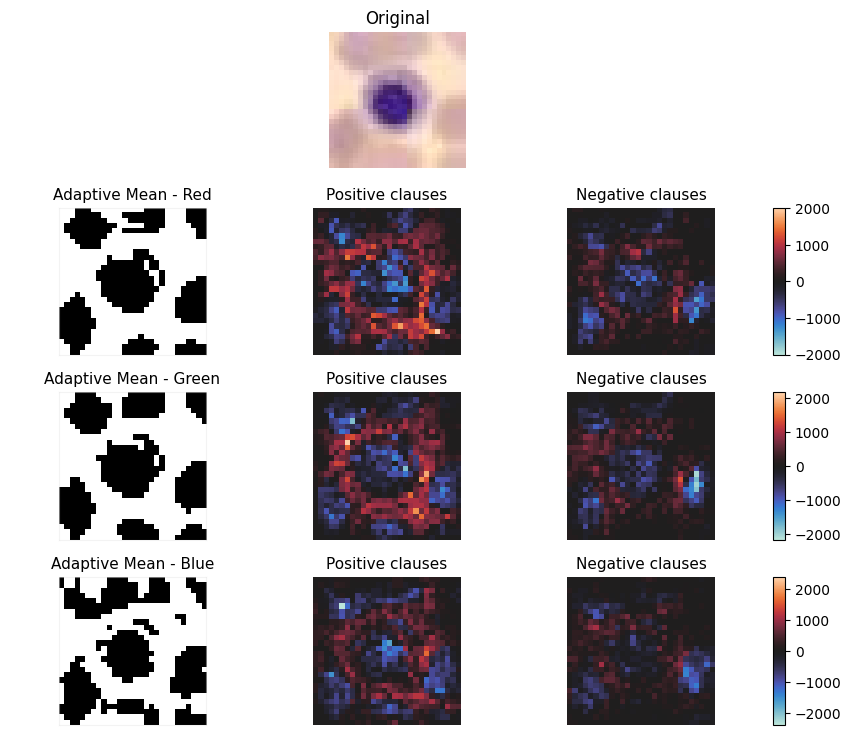

In [19]:
image_index =  3000
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 3 Local Examples 

In [20]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=3, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

3
Visualizing sample 1379  |  predicted class: 3
2026-04-10 15:37:44,642 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547a69dc0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c3_s1379_aggr.svg


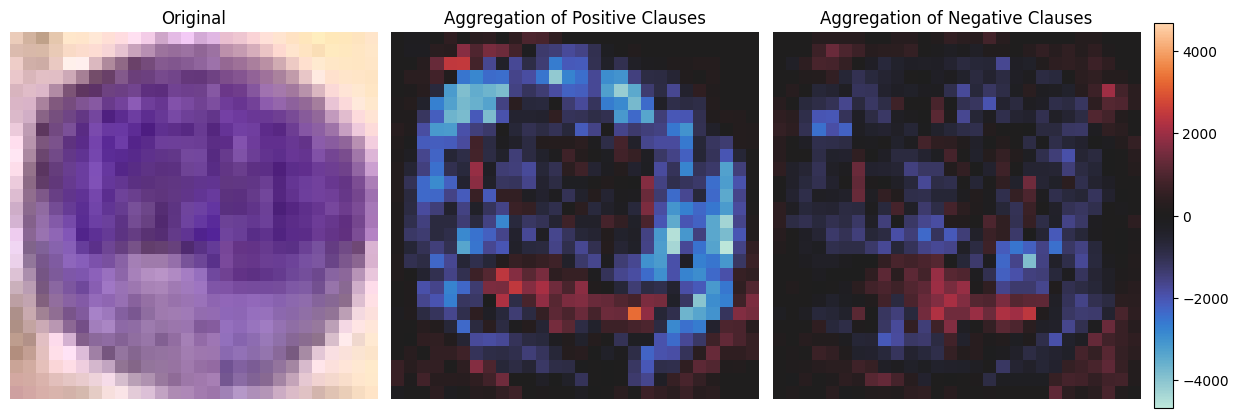

Visualizing sample 1379  |  predicted class: 3
2026-04-10 15:37:48,889 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78155aaefb90>
2026-04-10 15:37:48,924 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547a16a50>
2026-04-10 15:37:48,954 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549d95fd0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c3_s1379_chan.svg


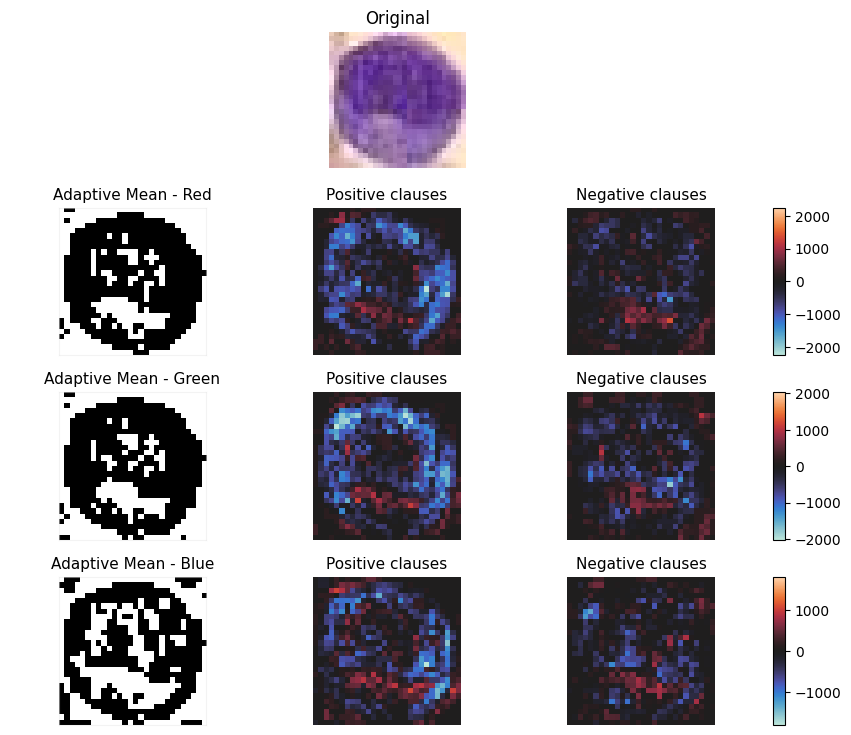

In [21]:
image_index =  1379
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

3
Visualizing sample 2101  |  predicted class: 3
2026-04-10 15:37:53,824 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549cba390>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c3_s2101_aggr.svg


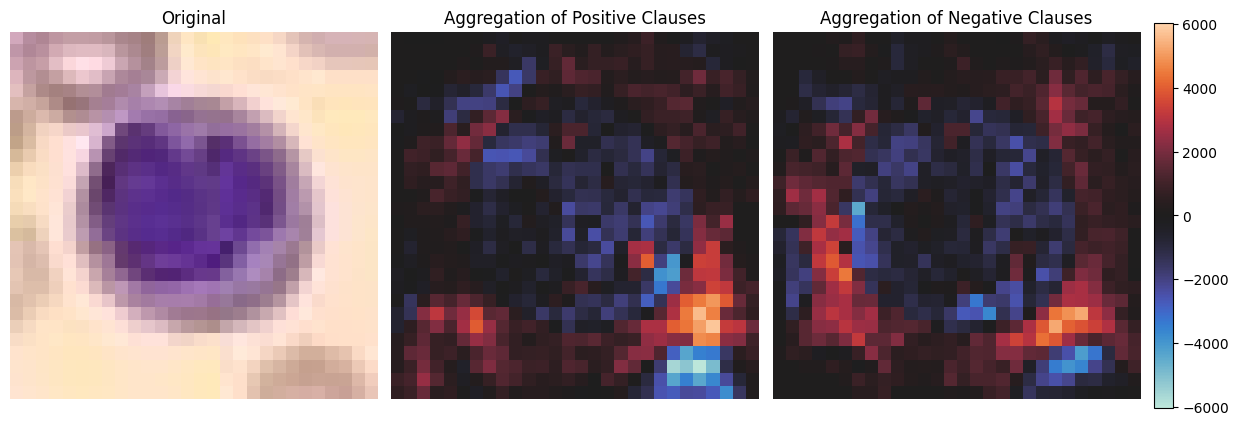

Visualizing sample 2101  |  predicted class: 3
2026-04-10 15:37:58,674 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549ba5e50>
2026-04-10 15:37:58,738 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547f8e180>
2026-04-10 15:37:58,767 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549bd1610>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c3_s2101_chan.svg


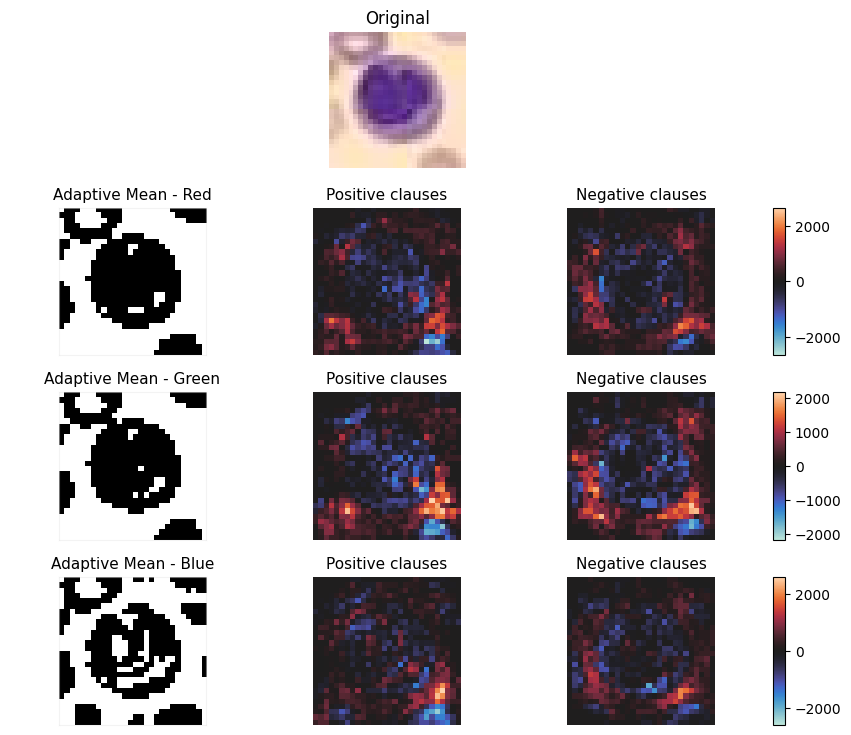

In [22]:
image_index =  2101
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

3


Visualizing sample 2211  |  predicted class: 3
2026-04-10 15:38:03,959 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547ed6450>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c3_s2211_aggr.svg


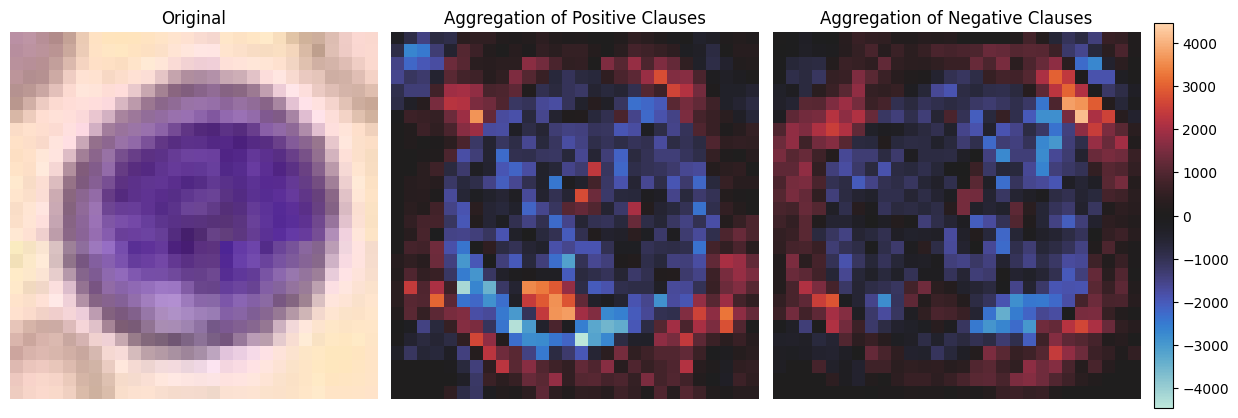

Visualizing sample 2211  |  predicted class: 3
2026-04-10 15:38:08,663 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549c8c740>
2026-04-10 15:38:08,693 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549ced010>
2026-04-10 15:38:08,721 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549de3080>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c3_s2211_chan.svg


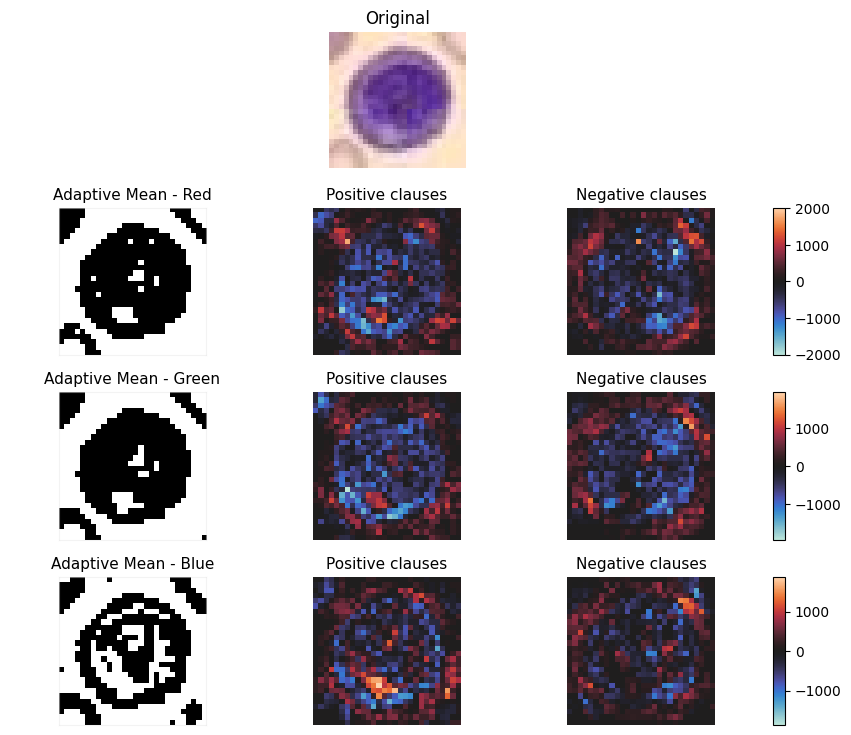

In [23]:
image_index =  2211
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 4 Local Examples 

In [24]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=4, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

4
Visualizing sample 2605  |  predicted class: 4
2026-04-10 15:38:13,537 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547f56090>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c4_s2605_aggr.svg


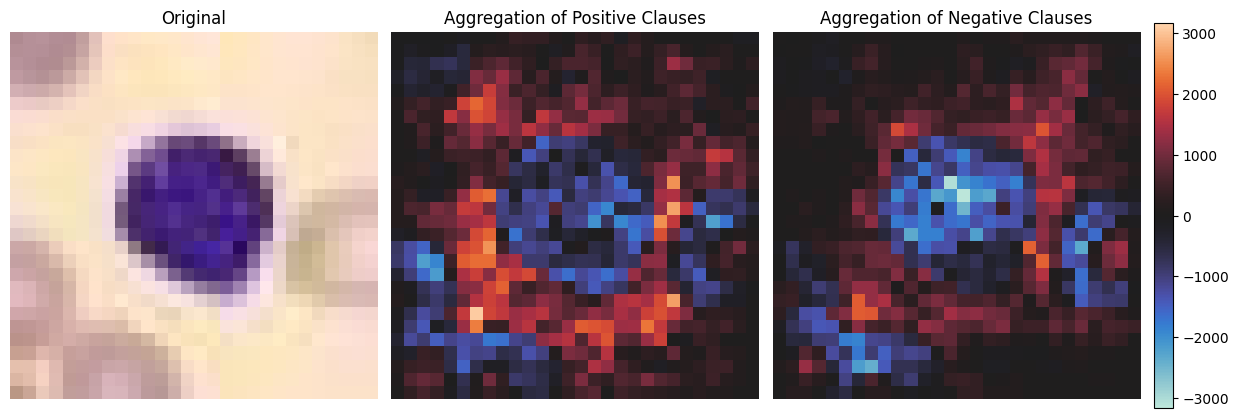

Visualizing sample 2605  |  predicted class: 4
2026-04-10 15:38:17,318 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781548132f60>
2026-04-10 15:38:17,346 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78155aaec980>
2026-04-10 15:38:17,372 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547c97890>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c4_s2605_chan.svg


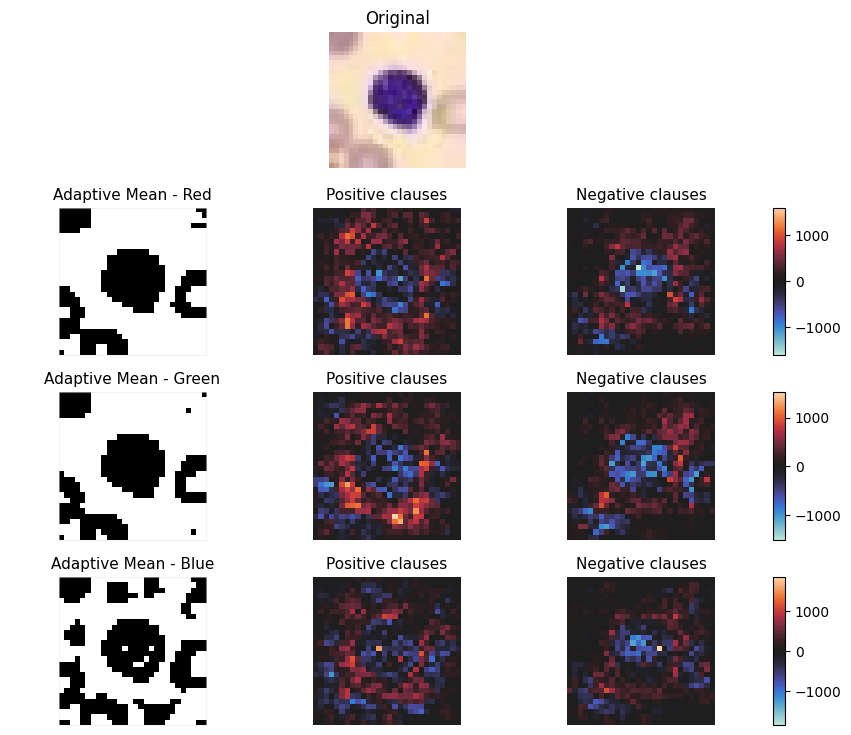

In [25]:
image_index =  2605
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

4


Visualizing sample 3053  |  predicted class: 4
2026-04-10 15:38:21,612 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547e03e00>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c4_s3053_aggr.svg


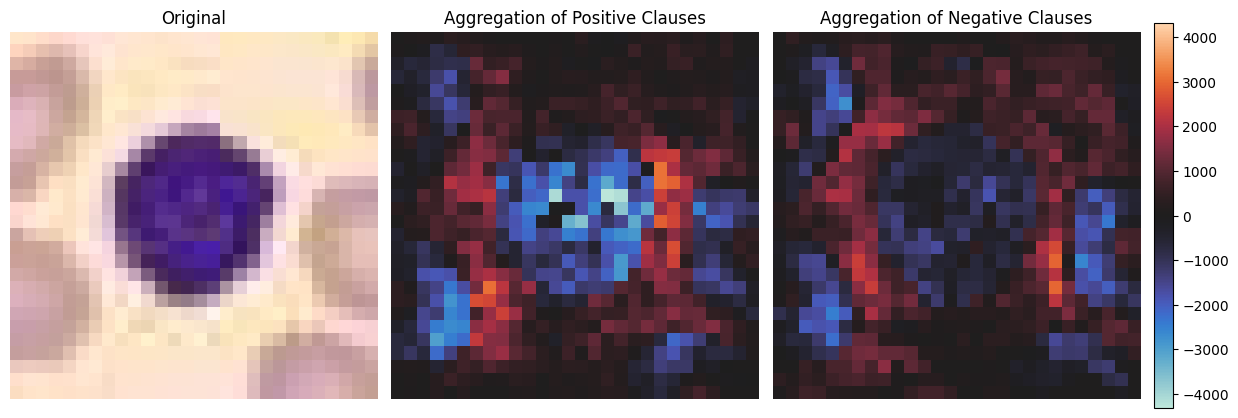

Visualizing sample 3053  |  predicted class: 4
2026-04-10 15:38:25,844 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154bef4dd0>
2026-04-10 15:38:25,871 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154bea78f0>
2026-04-10 15:38:25,898 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547e7a180>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c4_s3053_chan.svg


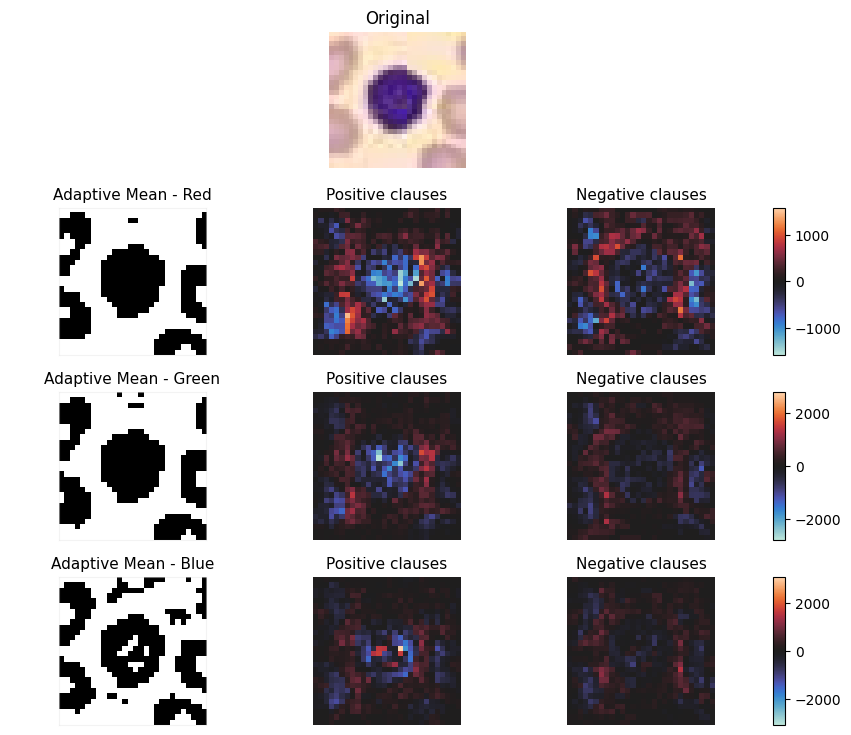

In [26]:
image_index =  3053
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

4
Visualizing sample 2132  |  predicted class: 4
2026-04-10 15:38:30,552 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547c1a840>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c4_s2132_aggr.svg


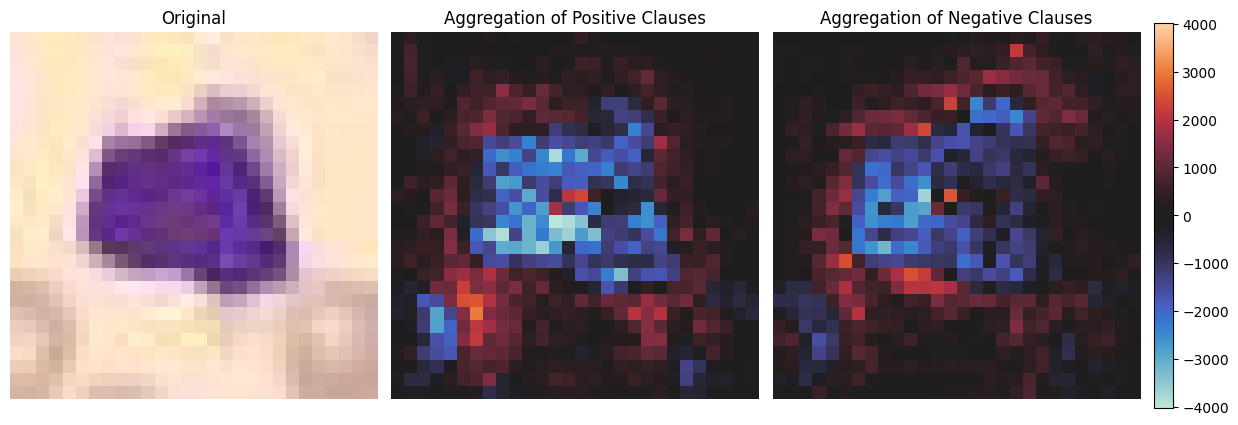

Visualizing sample 2132  |  predicted class: 4
2026-04-10 15:38:34,586 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154820f080>
2026-04-10 15:38:34,614 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547a589e0>
2026-04-10 15:38:34,643 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78155526f3b0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c4_s2132_chan.svg


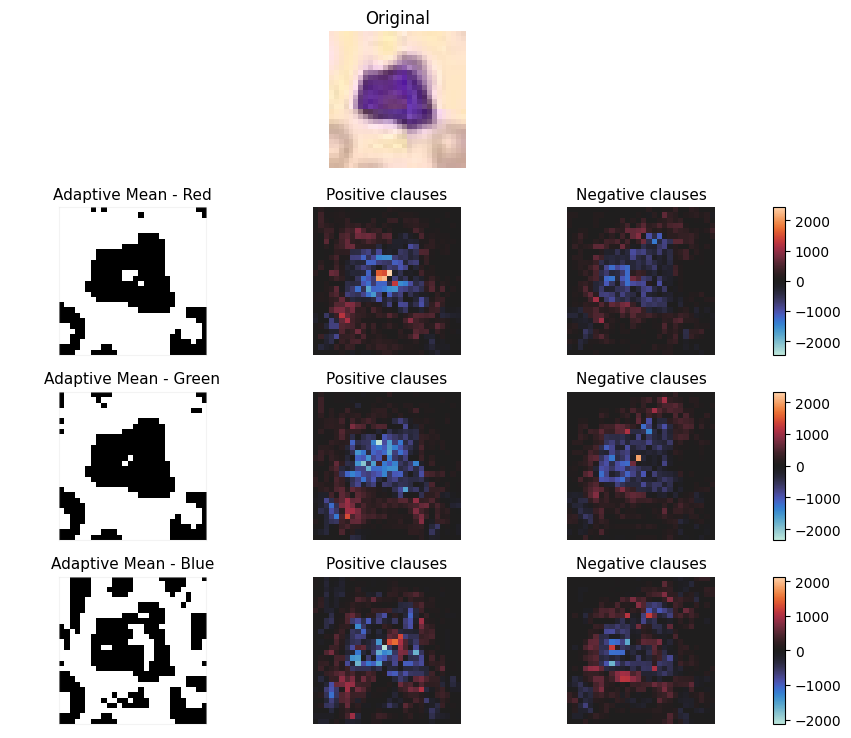

In [27]:
image_index =  2132
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 5 Local Examples 

In [28]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=5, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

5
Visualizing sample 2090  |  predicted class: 5
2026-04-10 15:38:39,102 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549db6660>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c5_s2090_aggr.svg


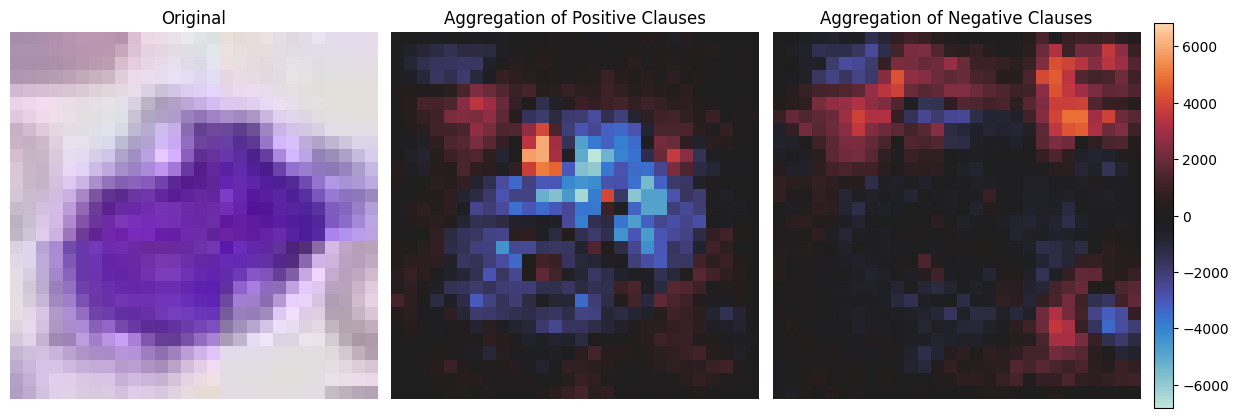

Visualizing sample 2090  |  predicted class: 5
2026-04-10 15:38:43,624 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549dbe180>
2026-04-10 15:38:43,652 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547c48110>
2026-04-10 15:38:43,685 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547d92cc0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c5_s2090_chan.svg


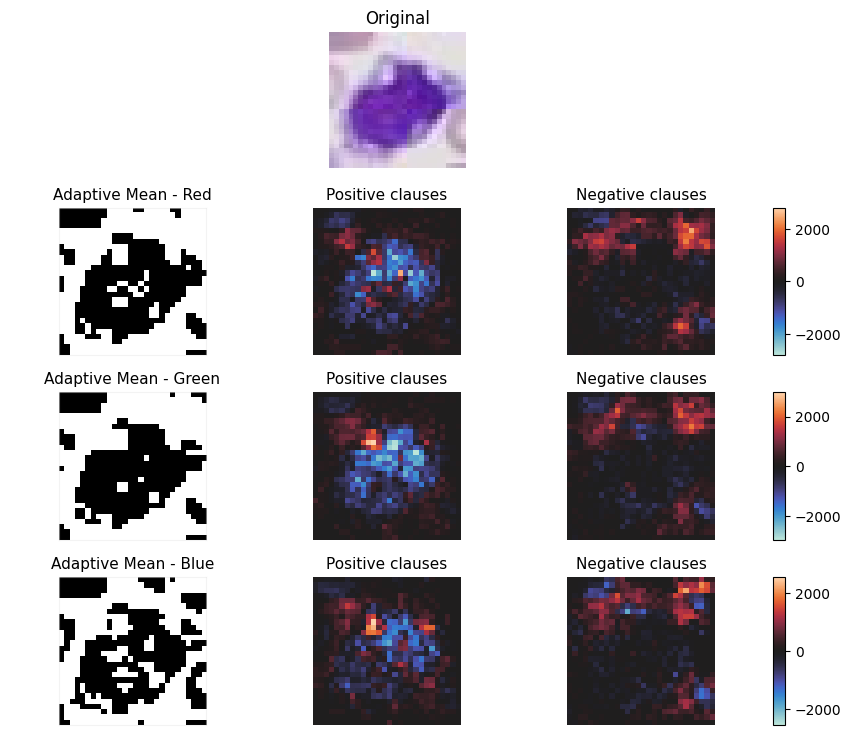

In [29]:
image_index =  2090
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

5
Visualizing sample 55  |  predicted class: 5
2026-04-10 15:38:48,132 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781548147440>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c5_s55_aggr.svg


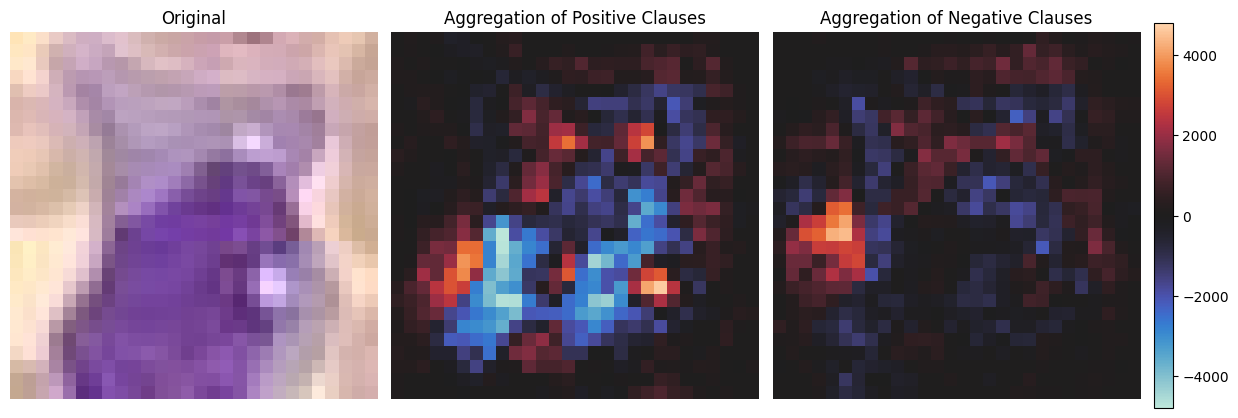

Visualizing sample 55  |  predicted class: 5
2026-04-10 15:38:52,304 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154bea7350>
2026-04-10 15:38:52,332 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547fb5130>
2026-04-10 15:38:52,359 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549be8d70>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c5_s55_chan.svg


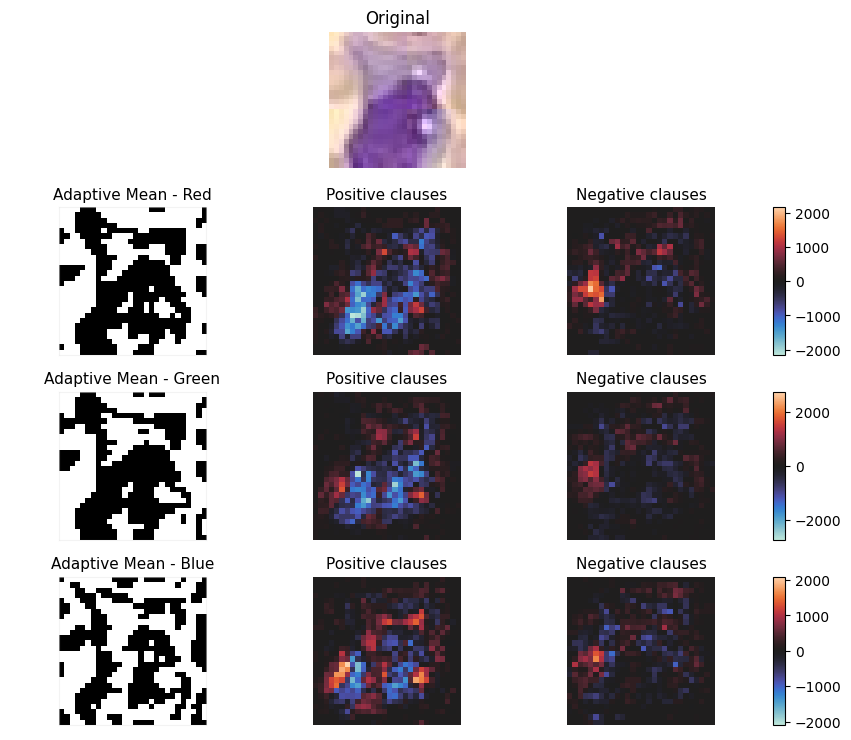

In [30]:
image_index =  55
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

5


Visualizing sample 2023  |  predicted class: 5
2026-04-10 15:38:56,905 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154bf2d4f0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c5_s2023_aggr.svg


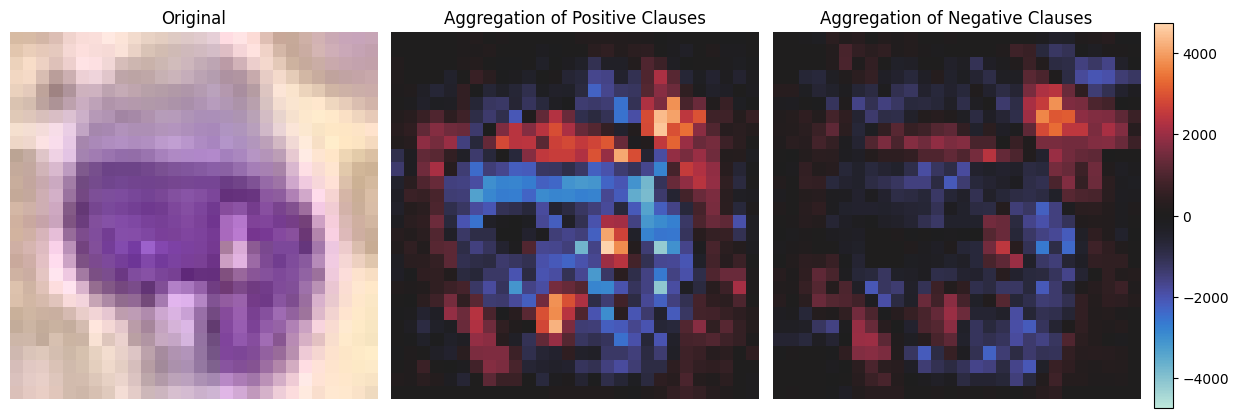

Visualizing sample 2023  |  predicted class: 5
2026-04-10 15:39:00,907 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781555231ca0>
2026-04-10 15:39:00,933 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154803fd10>
2026-04-10 15:39:00,960 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547fb6600>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c5_s2023_chan.svg


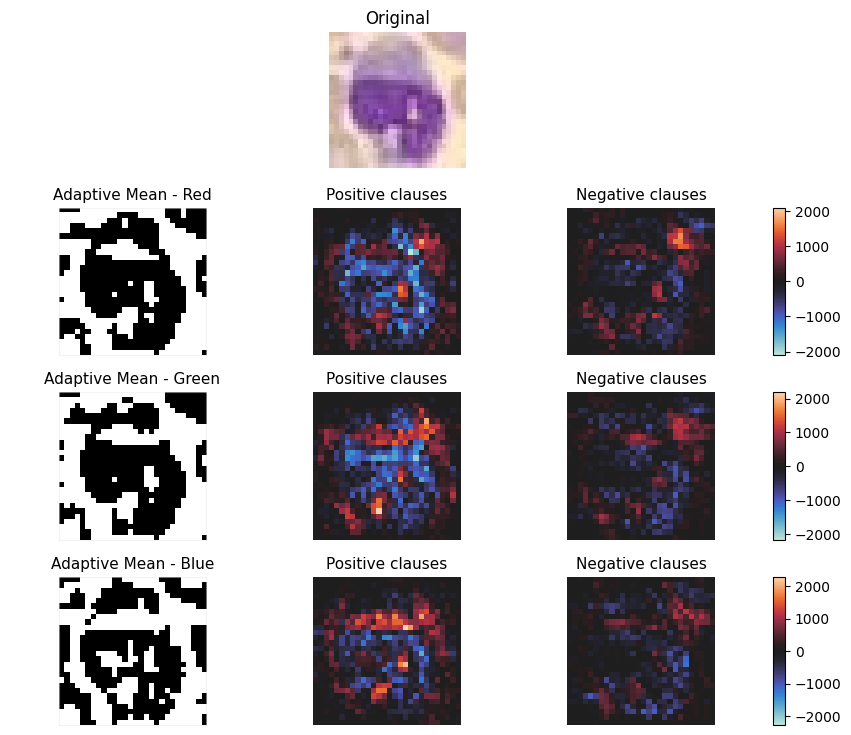

In [31]:
image_index =  2023
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 6 Local Examples 

In [32]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=6, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

6
Visualizing sample 2720  |  predicted class: 6
2026-04-10 15:39:05,198 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154827f7d0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c6_s2720_aggr.svg


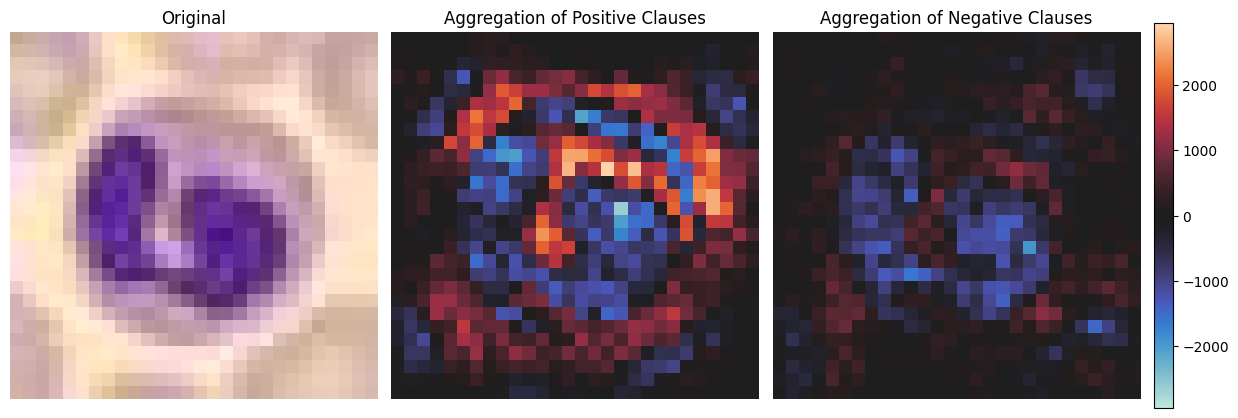

Visualizing sample 2720  |  predicted class: 6
2026-04-10 15:39:09,022 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549d87260>
2026-04-10 15:39:09,049 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547a6b5c0>
2026-04-10 15:39:09,077 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549d96870>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c6_s2720_chan.svg


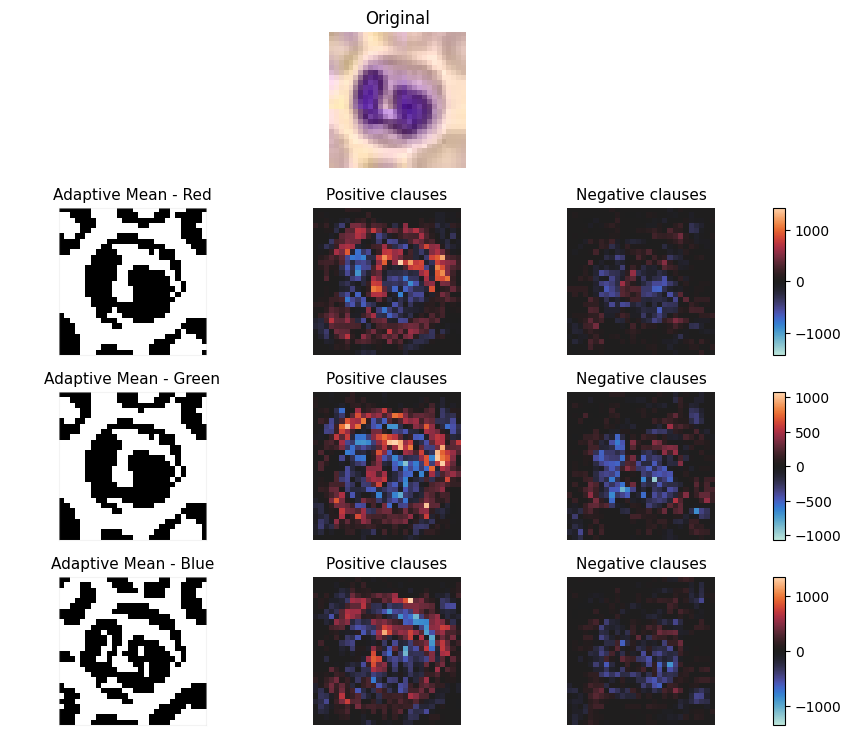

In [33]:
image_index =  2720
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

6
Visualizing sample 1874  |  predicted class: 6
2026-04-10 15:39:13,367 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154814cef0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c6_s1874_aggr.svg


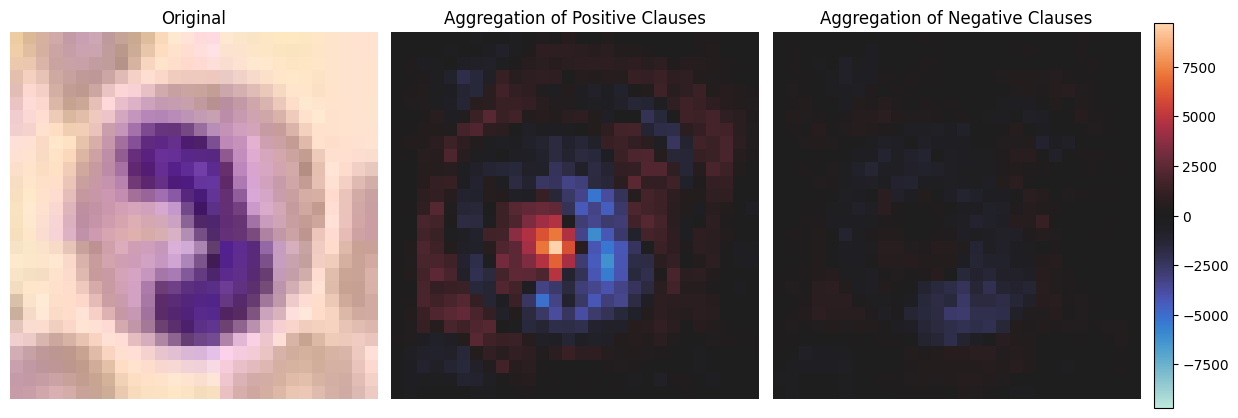

Visualizing sample 1874  |  predicted class: 6
2026-04-10 15:39:17,676 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78155526e4e0>
2026-04-10 15:39:17,846 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547f765d0>
2026-04-10 15:39:17,875 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7815480ba3c0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c6_s1874_chan.svg


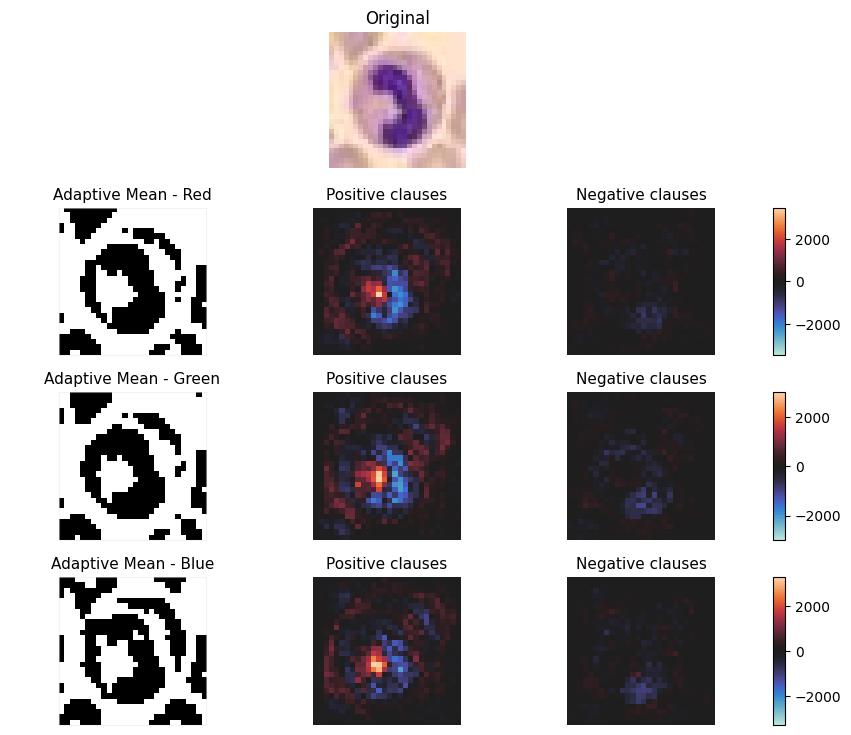

In [34]:
image_index =  1874
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

6


Visualizing sample 1355  |  predicted class: 6
2026-04-10 15:39:22,035 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547a14dd0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c6_s1355_aggr.svg


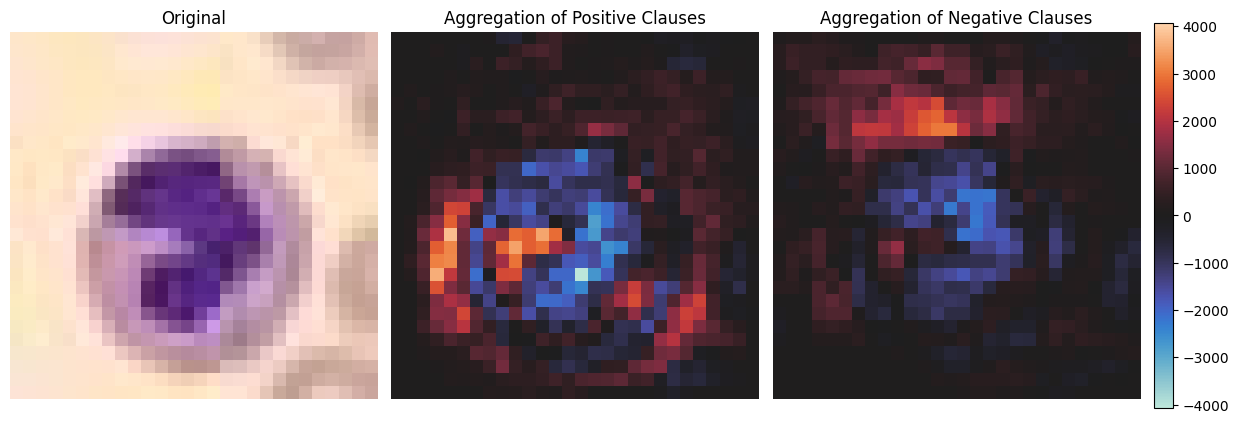

Visualizing sample 1355  |  predicted class: 6
2026-04-10 15:39:25,938 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154bec32c0>
2026-04-10 15:39:25,966 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78155529e5d0>
2026-04-10 15:39:25,994 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549d97740>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c6_s1355_chan.svg


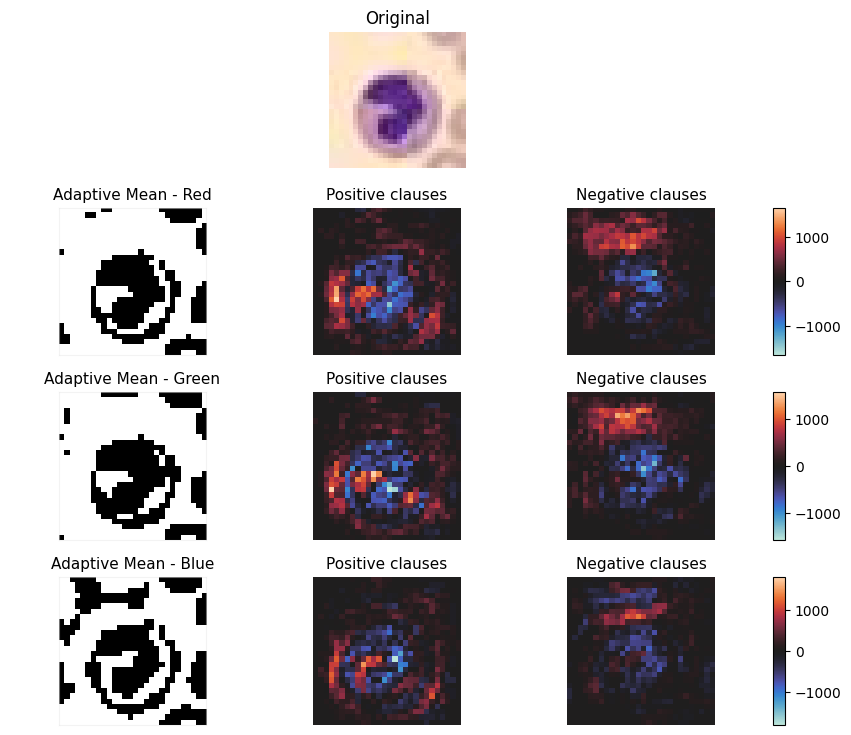

In [35]:
image_index =  1355
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 7 Local Examples 

In [36]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=7, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

7


Visualizing sample 3252  |  predicted class: 7
2026-04-10 15:39:30,115 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547a5b9b0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c7_s3252_aggr.svg


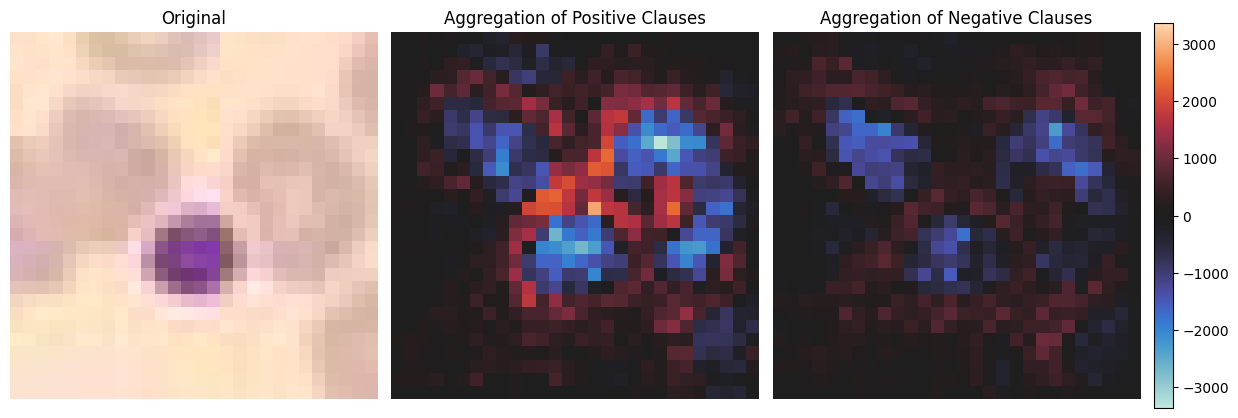

Visualizing sample 3252  |  predicted class: 7
2026-04-10 15:39:34,035 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154818f7d0>
2026-04-10 15:39:34,074 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549b49160>
2026-04-10 15:39:34,253 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7815552caea0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c7_s3252_chan.svg


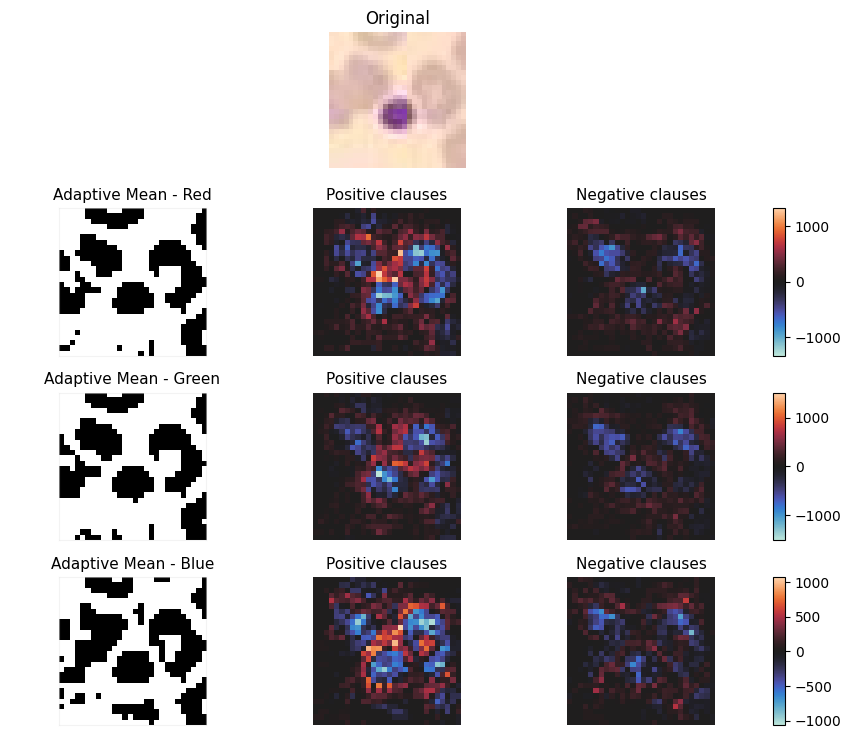

In [37]:
image_index =  3252
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

7
Visualizing sample 3183  |  predicted class: 7
2026-04-10 15:39:38,460 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549c8e6c0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c7_s3183_aggr.svg


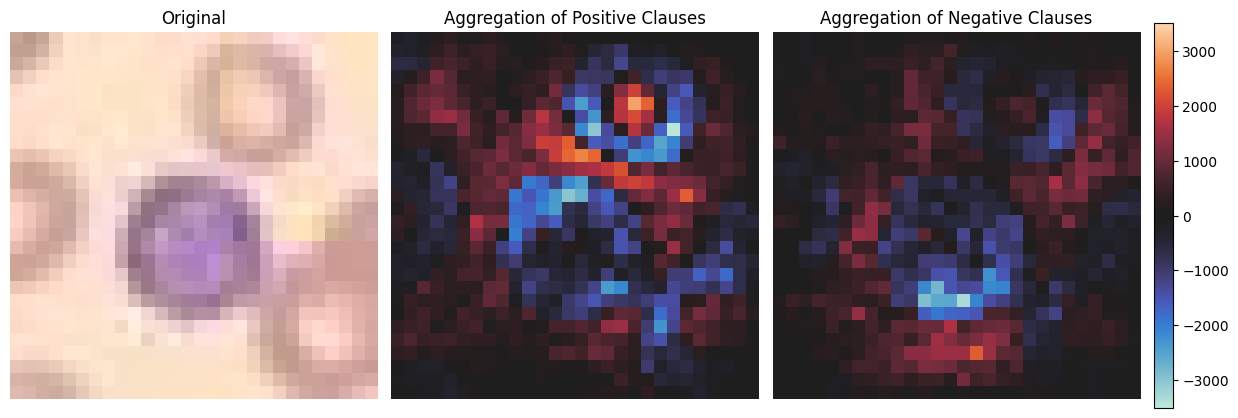

Visualizing sample 3183  |  predicted class: 7
2026-04-10 15:39:42,769 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154bea4e00>
2026-04-10 15:39:42,797 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78155526c740>
2026-04-10 15:39:42,831 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154bed6540>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c7_s3183_chan.svg


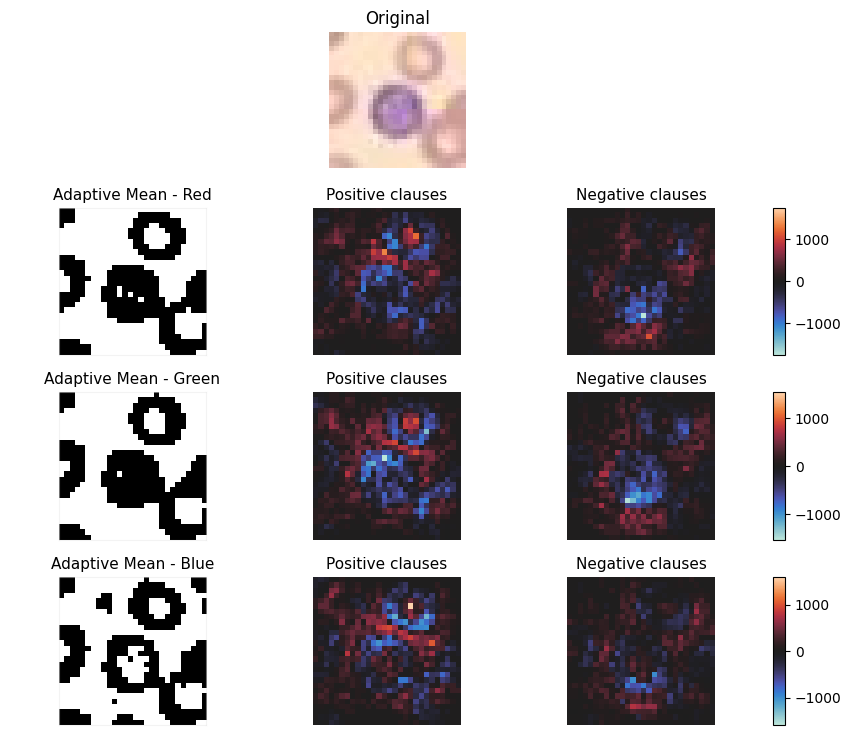

In [38]:
image_index =  3183
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

7
Visualizing sample 2705  |  predicted class: 7
2026-04-10 15:39:47,308 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78154be93740>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c7_s2705_aggr.svg


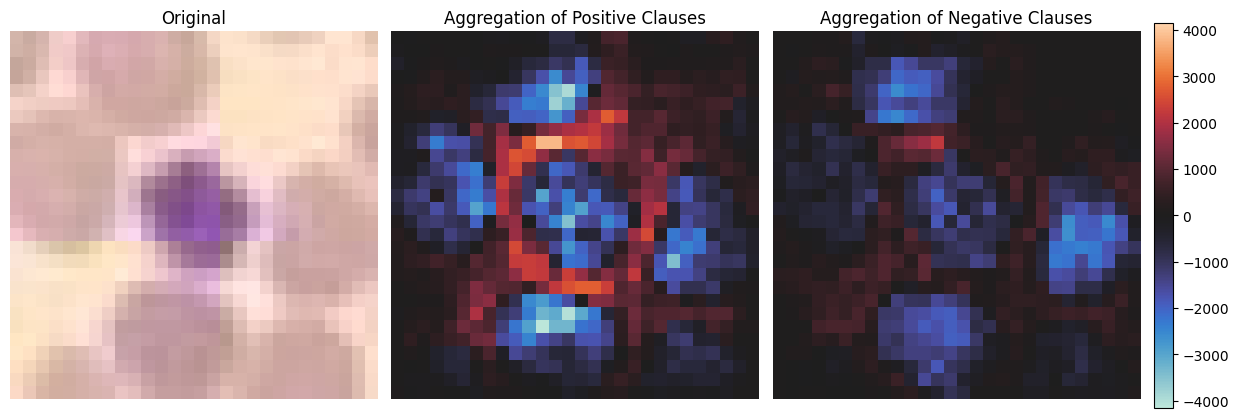

Visualizing sample 2705  |  predicted class: 7
2026-04-10 15:39:51,391 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781549de06b0>
2026-04-10 15:39:51,418 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781548013ad0>
2026-04-10 15:39:51,445 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x781547bcf500>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_lh_c7_s2705_chan.svg


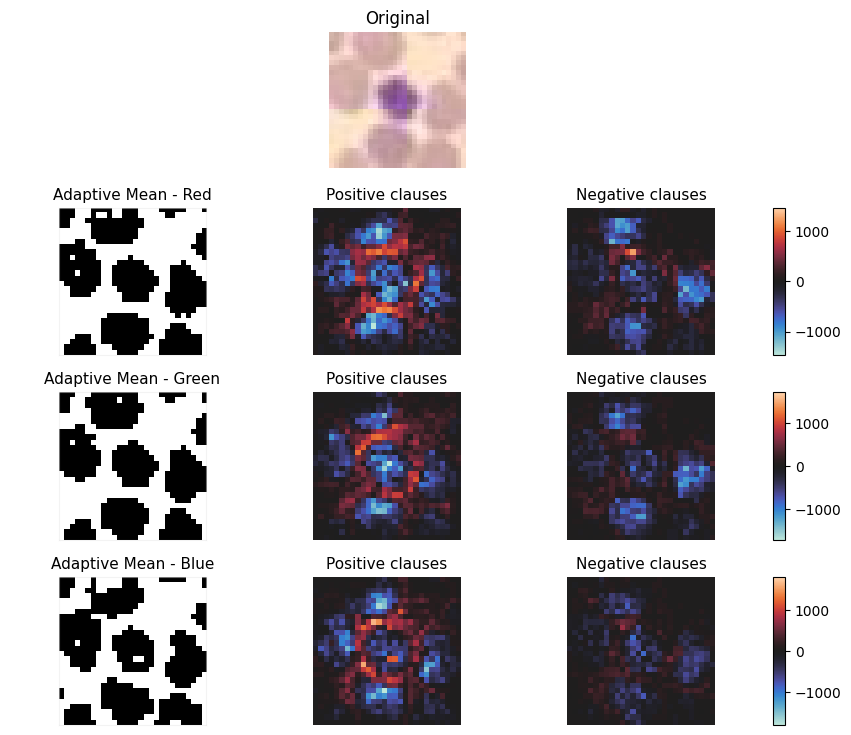

In [39]:
image_index =  2705
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Global Heatmap 0

In [6]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 0

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:34:12,206 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:34:12,210 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:34:12,234 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee8a4f66c00>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c0.svg


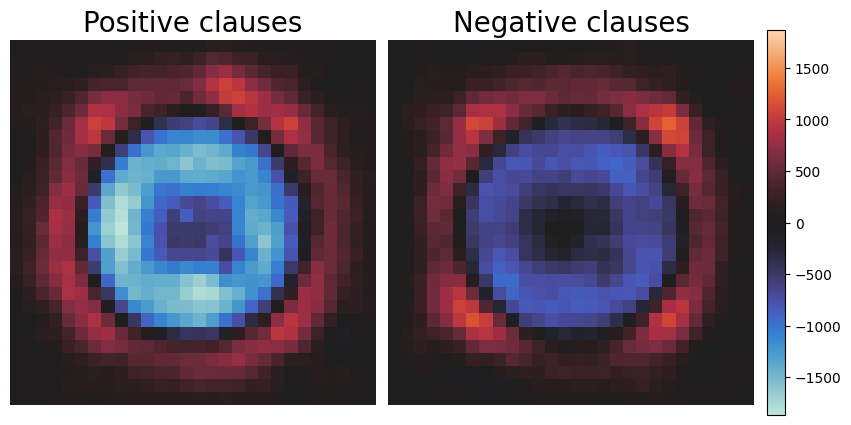

pos shape: (28, 28), min: -1868.42, max: 1065.01
neg shape: (28, 28), min: -962.67, max: 1259.36
saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c0.svg


In [7]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 1

In [8]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 1

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:34:12,650 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee886d05fa0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c1.svg


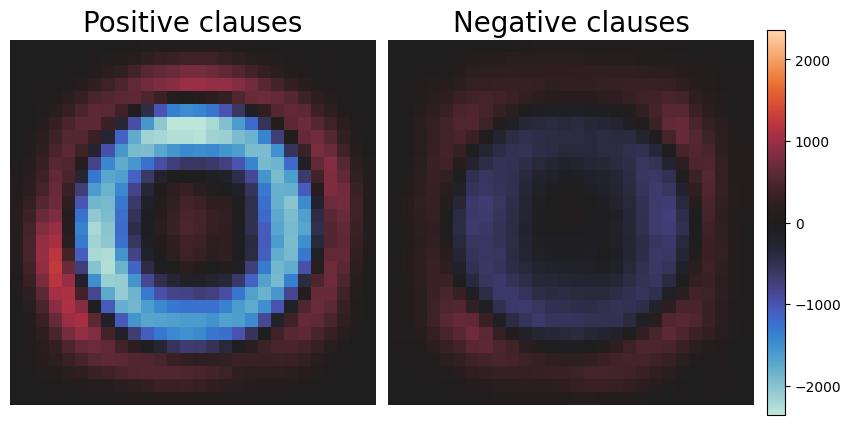

pos shape: (28, 28), min: -2361.49, max: 1271.24
neg shape: (28, 28), min: -741.66, max: 722.51
saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c1.svg


In [9]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 2

In [10]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 2

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:34:13,007 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee886c8cd10>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c2.svg


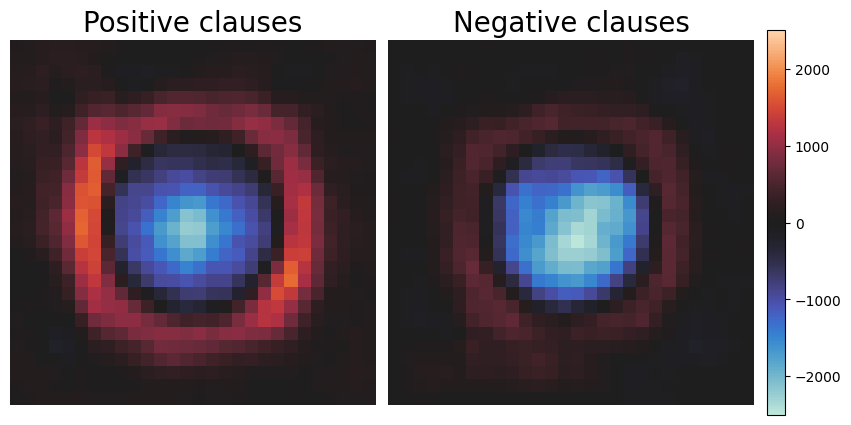

pos shape: (28, 28), min: -2216.41, max: 1742.64
neg shape: (28, 28), min: -2504.91, max: 721.94
saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c2.svg


In [11]:
target_class = 2
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 3

In [12]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 3

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:34:13,493 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee886c54c80>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c3.svg


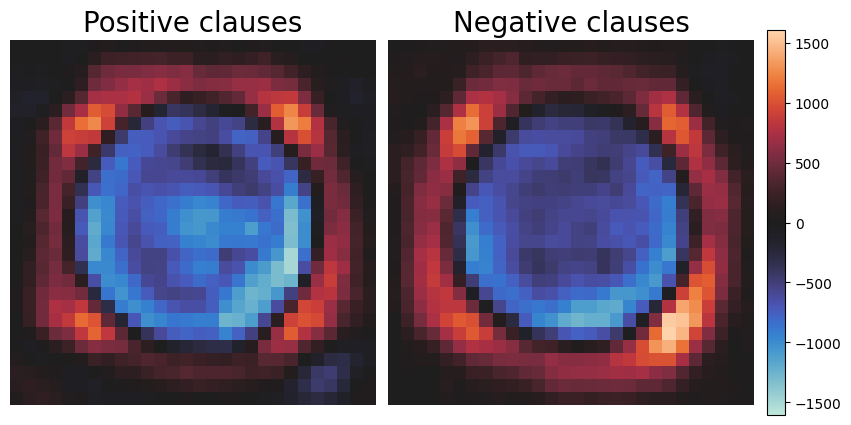

pos shape: (28, 28), min: -1496.67, max: 1319.38
neg shape: (28, 28), min: -1277.53, max: 1604.96
saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c3.svg


In [13]:
target_class = 3
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 4

In [14]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 4

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:34:13,898 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee8a409e2a0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c4.svg


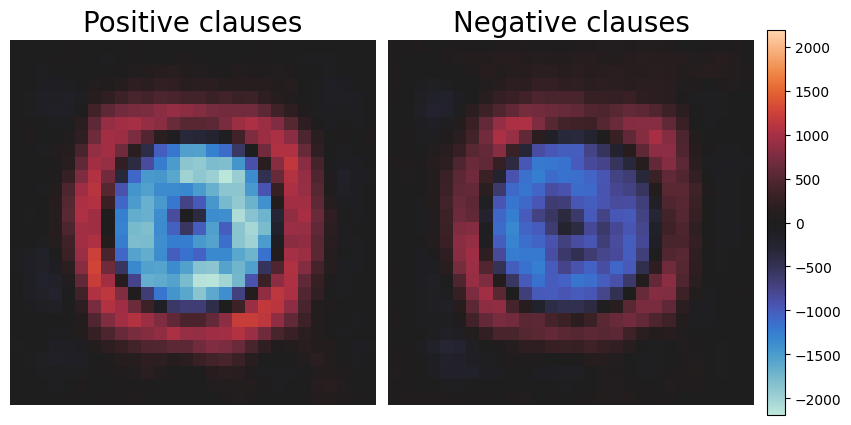

pos shape: (28, 28), min: -2189.99, max: 1282.62
neg shape: (28, 28), min: -1326.98, max: 1037.35
saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c4.svg


In [15]:
target_class = 4
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 5

In [16]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 5

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:34:14,307 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee87bdb6c30>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c5.svg


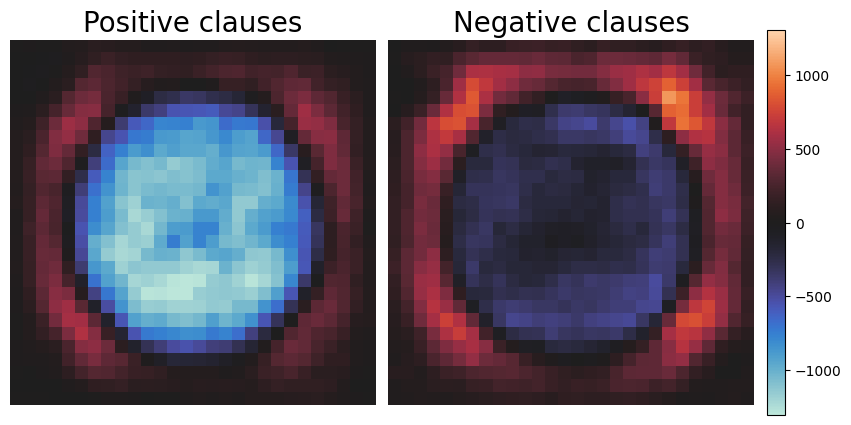

pos shape: (28, 28), min: -1306.20, max: 624.92
neg shape: (28, 28), min: -532.82, max: 1076.10
saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c5.svg


In [17]:
target_class = 5
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 6

In [18]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 6

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:34:14,695 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee87bca8cb0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c6.svg


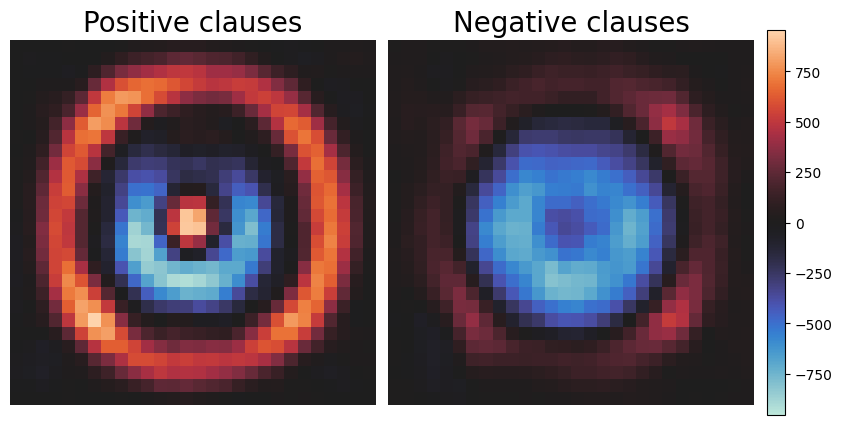

pos shape: (28, 28), min: -922.73, max: 955.21
neg shape: (28, 28), min: -812.13, max: 520.81
saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c6.svg


In [19]:
target_class = 6
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmaps 7

In [20]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 7

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:34:15,105 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7ee87bba02f0>
Saved to saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c7.svg


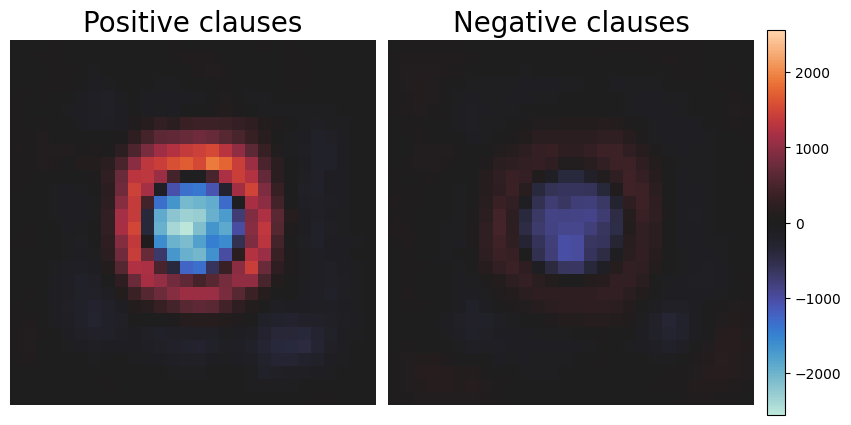

pos shape: (28, 28), min: -2558.60, max: 1904.95
neg shape: (28, 28), min: -1030.46, max: 472.80
saved_heatmaps/adaptive_mean/blood_adaptive_mean_gh_c7.svg


In [21]:
target_class = 7
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)